# Setup

In [1]:
import importlib
import lung_helpers

importlib.reload(lung_helpers)
from lung_helpers import *


In [2]:
# After you download the datasets, set this to point to their parent directory
BASE_DB_DIR = '../datasets/'

In [3]:
df_cohort = pd.read_csv(f"{BASE_DB_DIR}/FINAL_COHORT_LISTING.csv").set_index('main_index')

df_cohort_disc = df_cohort[df_cohort['cohort']=='discovery']
df_cohort_rad  = df_cohort[df_cohort['cohort']=='rad_valid']
df_cohort_path = df_cohort[df_cohort['cohort']=='path_valid']

print (len(df_cohort_disc), len(df_cohort_rad), len(df_cohort_path))

247 50 71


In [4]:
df_clinical = get_clinical_table_v2(
    path=f"{BASE_DB_DIR}/18193MSKMINDProjectM-OmnibusInventory_DATA_2021-12-20_1540-WITH-TB-and-SCANNER.csv", 
    main_index_col='dmp_pt_id',cohort=df_cohort_disc)
df_clinical_rad_valid  = get_clinical_table_v2(
    path=f"{BASE_DB_DIR}/18193MSKMINDProjectM-OmnibusInventory_DATA_2021-12-20_1540-WITH-TB-and-SCANNER.csv", 
    main_index_col='did_acc',cohort=df_cohort_rad)
df_clinical_path_valid = get_clinical_table_v2(
    path=f"{BASE_DB_DIR}/18193MSKMINDProjectM-OmnibusInventory_DATA_2021-12-20_1540-WITH-TB-and-SCANNER.csv", 
    main_index_col='pdl1_image_id',cohort=df_cohort_path)

df_outcomes            = df_clinical            [['label']].copy(deep=True)
df_outcomes_path_valid = df_clinical_path_valid [['label']].copy(deep=True)
df_outcomes_rad_valid  = df_clinical_rad_valid  [['label']].copy(deep=True)

247 62
50 11
71 21


In [5]:
sum(df_clinical['label']==0) / sum(df_clinical['label']==1)

0.33513513513513515

In [6]:
clinical_predictors = ['age', 
     'pack_years', 
     'ecog', 
     'albumin',
     'dnlr', 
     'brain_mets', 
     'liver_mets', 
     'tumor_burden', 
     'therapy_line', 
     'recieves_combo_therapy', 
     'site_lung', 
     'recieves_pdl1_therapy',
     'hist_adeno']

In [7]:
df_genomic = pd.read_parquet(f"{BASE_DB_DIR}/genomic_data_v3.parquet")
df_tmb     = df_genomic[['TMB']]
df_nontmb  = df_genomic.loc[:, ~df_genomic.columns.str.contains("TMB")]
df_pdl1    = pd.read_parquet (f"{BASE_DB_DIR}/PDL1_SCORE.parquet")
df_labs    = df_clinical[clinical_predictors]

df_radiology = pd.read_parquet(f"{BASE_DB_DIR}/LUNG_RADIOMICS_spacing1.0_MirpOn_Window1350.250_allImageTypes_bw20.parquet")
df_radiology_by_site = decorate_with_site_index(df_radiology)

df_radiology_valid = pd.read_parquet(f"{BASE_DB_DIR}/LUNG_RADIOMICS_spacing1.0_MirpOn_Window1350.250_allImageTypes_bw20_VALIDATION.parquet")
df_radiology_valid_by_site = decorate_with_site_index(df_radiology_valid)

df_texture = pd.read_parquet(f"{BASE_DB_DIR}/NEW_LUNG_glcm_Autocorrelation_v2_20x_stain1_PDL1.parquet")
df_texture_valid = pd.read_parquet(f"{BASE_DB_DIR}/NEW_LUNG_glcm_Autocorrelation_v2_20x_stain1_PDL1_VALIDATION.parquet")

df_glcm = pd.read_parquet(f"{BASE_DB_DIR}/LUNG_PATHOLOGY_PDL1_GLCM_V3.parquet")
df_glcm_valid = pd.read_parquet(f"{BASE_DB_DIR}/LUNG_PATHOLOGY_PDL1_GLCM_V3_VALIDATION.parquet")

In [8]:
modality_MASK = df_clinical[[]]
modality_dict = {}

modality_PC_full = prepare_rad_modality_by_size(modality_dict, df_radiology_by_site, modality_MASK, 'PC', 'rad_lesion_pc')
modality_PL_full = prepare_rad_modality_by_size(modality_dict, df_radiology_by_site, modality_MASK, 'PL', 'rad_lesion_pl')
modality_LN_full = prepare_rad_modality_by_size(modality_dict, df_radiology_by_site, modality_MASK, 'LN', 'rad_lesion_ln')

modality_LU_full = prepare_rad_modality_by_size(
    modality_dict, 
    df_radiology_by_site, 
    modality_MASK, 
    sites=['PC', 'PL', 'LN'], 
    name='rad_lesion_lu',
    sort='original_shape_MeshVolume', 
    ascending=False,
    reduce=True
)

prepare_other_modalities(modality_dict, df_texture, modality_MASK, 'path_ihc_pdl1')
prepare_other_modalities(modality_dict, df_glcm,    modality_MASK, 'path_ihc_glcm')
prepare_other_modalities(modality_dict, df_genomic, modality_MASK, 'gen_driver_mut_amp')
prepare_other_modalities(modality_dict, df_nontmb,  modality_MASK, 'gen_driver_non_tmb')
prepare_other_modalities(modality_dict, df_tmb,     modality_MASK, 'gen_driver_tmb')
prepare_other_modalities(modality_dict, df_pdl1,    modality_MASK, 'cnl_pdl1_score')
prepare_other_modalities(modality_dict, df_labs,    modality_MASK, 'cnl_dem_labs')

modality_dict['cnl_pdl1_score'] = - modality_dict['cnl_pdl1_score'] / 100.0

modality_MASK = modality_MASK.fillna(False)

pd.DataFrame(modality_MASK.sum(), columns=['Count (Modality)'])

(array([1.]), array([163], dtype=int64))
(array([3.]), array([21], dtype=int64))
(array([5.]), array([67], dtype=int64))
(array([1., 2., 3., 4., 5., 6.]), array([133,   6,   4,   5,  28,  11], dtype=int64))


,Count (Modality)
rad_lesion_pc,163
rad_lesion_pl,21
rad_lesion_ln,67
rad_lesion_lu,187
path_ihc_pdl1,105
path_ihc_glcm,105
gen_driver_mut_amp,247
gen_driver_non_tmb,247
gen_driver_tmb,247
cnl_pdl1_score,201


In [9]:
modality_mask_valid = df_clinical_rad_valid[[]]
modality_dict_valid = {}

modality_PC_full_valid = prepare_rad_modality_by_size(modality_dict_valid, df_radiology_valid_by_site, modality_mask_valid, 'PC', 'rad_lesion_pc')
modality_PL_full_valid = prepare_rad_modality_by_size(modality_dict_valid, df_radiology_valid_by_site, modality_mask_valid, 'PL', 'rad_lesion_pl')
modality_LN_full_valid = prepare_rad_modality_by_size(modality_dict_valid, df_radiology_valid_by_site, modality_mask_valid, 'LN', 'rad_lesion_ln')

modality_LU_full_valid = prepare_rad_modality_by_size(
    modality_dict_valid, 
    df_radiology_valid_by_site, 
    modality_mask_valid, 
    sites=['PC', 'PL', 'LN'], 
    name='rad_lesion_lu',
    sort='original_shape_MeshVolume', 
    ascending=False,
    reduce=True
)

modality_mask_valid = modality_mask_valid.fillna(False)

pd.DataFrame(modality_mask_valid.sum(), columns=['Count (Modality)'])


(array([1.]), array([40], dtype=int64))
(array([3.]), array([8], dtype=int64))
(array([5., 6.]), array([21,  1], dtype=int64))
(array([1., 3., 5., 6.]), array([31,  3,  9,  3], dtype=int64))


,Count (Modality)
rad_lesion_pc,40
rad_lesion_pl,8
rad_lesion_ln,22
rad_lesion_lu,46


In [10]:
modality_mask_path_valid = df_clinical_path_valid[[]]
modality_dict_path_valid = {}

prepare_other_modalities(modality_dict_path_valid, df_texture_valid, modality_mask_path_valid, 'path_ihc_pdl1')
prepare_other_modalities(modality_dict_path_valid, df_glcm_valid,    modality_mask_path_valid, 'path_ihc_glcm')

modality_mask_path_valid = modality_mask_path_valid.fillna(False)

pd.DataFrame(modality_mask_path_valid.sum(), columns=['Count (Modality)'])


,Count (Modality)
path_ihc_pdl1,52
path_ihc_glcm,52


In [11]:
import warnings
warnings.filterwarnings("ignore")

In [12]:
model_params = {'epochs':125, 'lr':0.01, 'alpha':0.001, 'beta':0.0, 'cross_modality_enabled':False}
model_params_gate_off = {'epochs':125, 'lr':0.01, 'alpha':0.001, 'beta':0.0, 'cross_modality_enabled':False, 'attention_gate_enabled':False}

dfs_rad_filters_lu = {
    0: {'l1_selection_df': modality_PC_full, 'kwargs':{'l1_strength': 0.1}},
    1: {'l1_selection_df': modality_PL_full, 'kwargs':{'l1_strength': 0.1}},
    2: {'l1_selection_df': modality_LN_full, 'kwargs':{'l1_strength': 0.1}},
    3: {'l1_selection_df': modality_LU_full, 'kwargs':{'l1_strength': 0.1}},
}

dfs_rad_filters = {
    0: {'l1_selection_df': modality_PC_full, 'kwargs':{'l1_strength': 0.1}},
    1: {'l1_selection_df': modality_PL_full, 'kwargs':{'l1_strength': 0.1}},
    2: {'l1_selection_df': modality_LN_full, 'kwargs':{'l1_strength': 0.1}},
}


dfs_rad_filters_pc = {
    0: {'l1_selection_df': modality_PC_full, 'kwargs':{'l1_strength': 0.1}},
}

In [13]:
if not 'summary_dfs' in locals():
    print ("init summary_dfs")
    summary_dfs = {}
    
if not 'summary_coefs' in locals():
    print ("init summary_coefs")
    summary_coefs = {}

if not 'summary_dfs_ss' in locals():
    print ("init summary_dfs_ss")
    summary_dfs_ss = {}

init summary_dfs
init summary_coefs
init summary_dfs_ss


In [14]:
importlib.reload(lung_helpers)
from lung_helpers import *

save_table_1A(df_clinical)

save_table_1B(df_clinical)

save_table_1D(df_clinical, df_genomic)

[save_table_1A] genomic_inventory_v1_FINAL.csv not found, skipping genomic join


# 10-CV Discovery Cohort

In [15]:
summary_dfs['LR Clinical'], summary_coefs['LR Clinical'] = train_LR(modality_dict['cnl_dem_labs'].dropna(), df_outcomes.loc[modality_dict['cnl_dem_labs'].dropna().index])
summary_dfs['LR Clinical-Albumin'], summary_coefs['LR Clinical-Albumin'] = train_LR(modality_dict['cnl_dem_labs'].dropna()[['albumin']], df_outcomes.loc[modality_dict['cnl_dem_labs'].dropna().index])

summary_dfs['LR Rad-PC'], summary_coefs['LR Rad-PC'] = train_LR(modality_dict['rad_lesion_pc'].dropna(), df_outcomes.loc[modality_dict['rad_lesion_pc'].dropna().index], dfs_rad_filters[0])
summary_dfs['LR Rad-PL'], summary_coefs['LR Rad-PL'] = train_LR(modality_dict['rad_lesion_pl'].dropna(), df_outcomes.loc[modality_dict['rad_lesion_pl'].dropna().index], dfs_rad_filters[1])
summary_dfs['LR Rad-LN'], summary_coefs['LR Rad-LN'] = train_LR(modality_dict['rad_lesion_ln'].dropna(), df_outcomes.loc[modality_dict['rad_lesion_ln'].dropna().index], dfs_rad_filters[2])

summary_dfs['LR Rad-LU'], _       = train_LR(modality_dict['rad_lesion_lu'].dropna(), df_outcomes.loc[modality_dict['rad_lesion_lu'].dropna().index], dfs_rad_filters_lu[3])
summary_dfs['LR Rad-Average']     = average_models(summary_dfs,['LR Rad-PC', 'LR Rad-PL', 'LR Rad-LN'])

summary_dfs['LR IHC-G'], summary_coefs['LR IHC-G']        = train_LR(df_glcm, df_outcomes.loc[df_glcm.index], None)
summary_dfs['LR IHC-A'], summary_coefs['LR IHC-A']        = train_LR(df_texture, df_outcomes.loc[df_texture.index], None)
summary_dfs['LR PDL1-TPS'], _     = train_LR(df_pdl1, df_outcomes.loc[df_pdl1.index], None)

summary_dfs['LR Gen-Only-TMB'], summary_coefs['LR Gen-Only-TMB'] = train_LR(df_tmb, df_outcomes.loc[df_tmb.index], None)
summary_dfs['LR Gen-No-TMB'], summary_coefs['LR Gen-No-TMB']   = train_LR(df_nontmb, df_outcomes.loc[df_tmb.index], None)
summary_dfs['LR Gen-Combined'], summary_coefs['LR Gen-Combined'] = train_LR(df_genomic, df_outcomes.loc[df_genomic.index], None)
summary_dfs['LR Gen-Average']  = average_models(summary_dfs,['LR Gen-Only-TMB', 'LR Gen-No-TMB'])

summary_dfs['LR Path-A-Average'] = average_models(summary_dfs,['LR IHC-A', 'LR PDL1-TPS'])
summary_dfs['LR Path-G-Average'] = average_models(summary_dfs,['LR IHC-G', 'LR PDL1-TPS'])

100%|██████████| 10/10 [00:00<00:00, 125.32it/s]
Fold [10] AUC = 0.570 +/- 0.089 95% CL
Avg N features: 13.0
100%|██████████| 10/10 [00:00<00:00, 290.92it/s]
Fold [10] AUC = 0.453 +/- 0.087 95% CL
Avg N features: 1.0
100%|██████████| 10/10 [00:10<00:00,  1.08s/it]
Fold [10] AUC = 0.641 +/- 0.096 95% CL
Avg N features: 34.9
100%|██████████| 10/10 [00:05<00:00,  1.96it/s]
Fold [10] AUC = 0.231 +/- 0.208 95% CL
Avg N features: 10.2
100%|██████████| 10/10 [00:08<00:00,  1.21it/s]
Fold [10] AUC = 0.681 +/- 0.131 95% CL
Avg N features: 67.0
100%|██████████| 10/10 [00:10<00:00,  1.09s/it]
Fold [10] AUC = 0.596 +/- 0.087 95% CL
Avg N features: 28.8
100%|██████████| 10/10 [00:00<00:00, 11.51it/s]
Fold [10] AUC = 0.634 +/- 0.111 95% CL
Avg N features: 150.0
100%|██████████| 10/10 [00:00<00:00, 56.38it/s]
Fold [10] AUC = 0.624 +/- 0.112 95% CL
Avg N features: 18.0
100%|██████████| 10/10 [00:00<00:00, 284.57it/s]
Fold [10] AUC = 0.729 +/- 0.082 95% CL
Avg N features: 1.0
100%|██████████| 10/10 [00

In [16]:
data, mask, labels = get_training_data(['gen_driver_tmb'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM TMB'], _ = train(data, mask, labels, {}, model_params_gate_off)

data, mask, labels = get_training_data(['cnl_pdl1_score'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM PDL1'], _ = train(data, mask, labels, {}, model_params_gate_off)

data, mask, labels = get_training_data(['gen_driver_tmb', 'cnl_pdl1_score'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM TMB+PDL1'], _ = train(data, mask, labels, {}, model_params_gate_off)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM Rad'], _ = train(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'rad_lesion_lu'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM Rad-LU'], _ = train(data, mask, labels, dfs_rad_filters_lu, model_params)

data, mask, labels = get_training_data(['path_ihc_pdl1'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM IHC-A'], _ = train(data, mask, labels, {}, model_params_gate_off)

data, mask, labels = get_training_data(['gen_driver_mut_amp'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM Gen'], _ = train(data, mask, labels, {}, model_params_gate_off)

data, mask, labels = get_training_data(['cnl_pdl1_score', 'gen_driver_mut_amp'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM TMB+PDL1'], _ = train(data, mask, labels, {}, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_pdl1'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM Rad+IHC-A'], _ = train(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_glcm'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM Rad+IHC-G'], _ = train(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'gen_driver_mut_amp'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM Rad+Gen'], _ = train(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['path_ihc_pdl1', 'gen_driver_mut_amp'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM IHC-A+Gen'], _ = train(data, mask, labels, {}, model_params)

data, mask, labels = get_training_data(['path_ihc_glcm', 'gen_driver_mut_amp'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM IHC-G+Gen'], _ = train(data, mask, labels, {}, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_pdl1', 'gen_driver_mut_amp'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM Rad+IHC-A+Gen'], summary_coefs['DyAM Rad+IHC-A+Gen'] = train(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_glcm', 'gen_driver_mut_amp'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM Rad+IHC-G+Gen'], summary_coefs['DyAM Rad+IHC-G+Gen'] = train(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_pdl1', 'gen_driver_non_tmb', 'cnl_pdl1_score'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM Rad+IHC-A+MutAmp'], _ = train(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_pdl1', 'gen_driver_mut_amp', 'cnl_pdl1_score'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM Rad+IHC-A+Gen+PDL1'], summary_coefs['DyAM Rad+IHC-A+Gen+PDL1']  = train(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_glcm', 'gen_driver_mut_amp', 'cnl_pdl1_score'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM Rad+IHC-G+Gen+PDL1'], summary_coefs['DyAM Rad+IHC-G+Gen+PDL1']  = train(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_pdl1', 'gen_driver_non_tmb', 'gen_driver_tmb', 'cnl_pdl1_score'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM Rad+IHC-A+Gen+TMB+PDL1'], _ = train(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_pdl1', 'gen_driver_mut_amp', 'cnl_pdl1_score', 'cnl_dem_labs'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM Rad+IHC-A+Gen+PDL1+Labs'], _ = train(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_glcm', 'gen_driver_mut_amp', 'cnl_pdl1_score', 'cnl_dem_labs'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM Rad+IHC-G+Gen+PDL1+Labs'], _ = train(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_pdl1', 'gen_driver_non_tmb', 'gen_driver_tmb', 'cnl_pdl1_score'], modality_dict, modality_MASK, df_outcomes)
summary_dfs['DyAM Rad+Path+Gen+TMB+PDL1 (Full Fit)'] = train_eval_all(data, mask, labels, dfs_rad_filters, model_params, train_px=labels.index, valid_px=labels.index)

summary_dfs['LR Multimodal-Average'] = average_models(summary_dfs,
 ['LR Rad-PC', 'LR Rad-PL', 'LR Rad-LN', 'LR IHC-A', 'LR PDL1-TPS', 'LR Gen-Combined']
)


100%|██████████| 10/10 [00:03<00:00,  2.67it/s]
Fold [10] AUC = 0.615 +/- 0.084 95% CL
100%|██████████| 10/10 [00:02<00:00,  3.63it/s]
Fold [10] AUC = 0.708 +/- 0.086 95% CL
100%|██████████| 10/10 [00:04<00:00,  2.35it/s]
Fold [10] AUC = 0.705 +/- 0.077 95% CL
100%|██████████| 10/10 [00:25<00:00,  2.55s/it]
Fold [10] AUC = 0.687 +/- 0.080 95% CL
100%|██████████| 10/10 [00:36<00:00,  3.64s/it]
Fold [10] AUC = 0.677 +/- 0.079 95% CL
100%|██████████| 10/10 [00:01<00:00,  5.25it/s]
Fold [10] AUC = 0.606 +/- 0.113 95% CL
100%|██████████| 10/10 [00:02<00:00,  3.44it/s]
Fold [10] AUC = 0.676 +/- 0.074 95% CL
100%|██████████| 10/10 [00:04<00:00,  2.40it/s]
Fold [10] AUC = 0.693 +/- 0.070 95% CL
100%|██████████| 10/10 [00:26<00:00,  2.68s/it]
Fold [10] AUC = 0.673 +/- 0.074 95% CL
100%|██████████| 10/10 [00:27<00:00,  2.71s/it]
Fold [10] AUC = 0.701 +/- 0.073 95% CL
100%|██████████| 10/10 [00:27<00:00,  2.73s/it]
Fold [10] AUC = 0.738 +/- 0.069 95% CL
100%|██████████| 10/10 [00:04<00:00,  2.17i

In [17]:
importlib.reload(lung_helpers)
from lung_helpers import *

summary_dfs_ss['LR Clinical']         = train_LR_subsample(modality_dict['cnl_dem_labs'].dropna(), df_outcomes.loc[modality_dict['cnl_dem_labs'].dropna().index])
summary_dfs_ss['LR Clinical-Albumin'] = train_LR_subsample(modality_dict['cnl_dem_labs'].dropna()[['albumin']], df_outcomes.loc[modality_dict['cnl_dem_labs'].dropna().index])

summary_dfs_ss['LR Rad-PC'] = train_LR_subsample(modality_dict['rad_lesion_pc'].dropna(), df_outcomes.loc[modality_dict['rad_lesion_pc'].dropna().index], dfs_rad_filters[0])
summary_dfs_ss['LR Rad-PL'] = train_LR_subsample(modality_dict['rad_lesion_pl'].dropna(), df_outcomes.loc[modality_dict['rad_lesion_pl'].dropna().index], dfs_rad_filters[1])
summary_dfs_ss['LR Rad-LN'] = train_LR_subsample(modality_dict['rad_lesion_ln'].dropna(), df_outcomes.loc[modality_dict['rad_lesion_ln'].dropna().index], dfs_rad_filters[2])
summary_dfs_ss['LR Rad-LU'] = train_LR_subsample(modality_dict['rad_lesion_lu'].dropna(), df_outcomes.loc[modality_dict['rad_lesion_lu'].dropna().index], dfs_rad_filters_lu[3])

summary_dfs_ss['LR IHC-A']       = train_LR_subsample(df_texture, df_outcomes.loc[df_texture.index], None)
summary_dfs_ss['LR IHC-G'] = train_LR_subsample(df_glcm, df_outcomes.loc[df_glcm.index], None)
summary_dfs_ss['LR PDL1-TPS']    = train_LR_subsample(df_pdl1, df_outcomes.loc[df_pdl1.index], None)

summary_dfs_ss['LR Gen-Only-TMB'] = train_LR_subsample(df_tmb, df_outcomes.loc[df_tmb.index], None)
summary_dfs_ss['LR Gen-No-TMB']   = train_LR_subsample(df_nontmb, df_outcomes.loc[df_tmb.index], None)
summary_dfs_ss['LR Gen-Combined'] = train_LR_subsample(df_genomic, df_outcomes.loc[df_genomic.index], None)


100%|██████████| 20/20 [00:00<00:00, 202.10it/s]
0.5450877183638736
100%|██████████| 20/20 [00:00<00:00, 394.07it/s]
0.5156788256771551
100%|██████████| 20/20 [00:20<00:00,  1.01s/it]
0.5947257712643087
100%|██████████| 20/20 [00:08<00:00,  2.34it/s]
0.4212962962962962
100%|██████████| 20/20 [00:11<00:00,  1.77it/s]
0.59279433859791
100%|██████████| 20/20 [00:20<00:00,  1.04s/it]
0.6128554706151956
100%|██████████| 20/20 [00:00<00:00, 65.01it/s]
0.6440580814687958
100%|██████████| 20/20 [00:01<00:00, 17.02it/s]
0.627750159893017
100%|██████████| 20/20 [00:00<00:00, 402.77it/s]
0.7403391547915957
100%|██████████| 20/20 [00:00<00:00, 455.34it/s]
0.5977488768797279
100%|██████████| 20/20 [00:00<00:00, 303.34it/s]
0.6158344600468434
100%|██████████| 20/20 [00:00<00:00, 295.52it/s]
0.6360163729853248


In [18]:

data, mask, labels = get_training_data(['gen_driver_tmb'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM TMB'] = train_subsample(data, mask, labels, {}, model_params_gate_off)

data, mask, labels = get_training_data(['cnl_pdl1_score'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM PDL1'] = train_subsample(data, mask, labels, {}, model_params_gate_off)

data, mask, labels = get_training_data(['gen_driver_tmb', 'cnl_pdl1_score'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM TMB+PDL1'] = train_subsample(data, mask, labels, {}, model_params_gate_off)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM Rad'] = train_subsample(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'rad_lesion_lu'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM Rad-LU'] = train_subsample(data, mask, labels, dfs_rad_filters_lu, model_params)

data, mask, labels = get_training_data(['path_ihc_pdl1'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM IHC-A'] = train_subsample(data, mask, labels, {}, model_params_gate_off)

data, mask, labels = get_training_data(['gen_driver_mut_amp'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM Gen'] = train_subsample(data, mask, labels, {}, model_params_gate_off)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_pdl1'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM Rad+IHC-A'] = train_subsample(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'gen_driver_mut_amp'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM Rad+Gen'] = train_subsample(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['path_ihc_pdl1', 'gen_driver_mut_amp'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM IHC-A+Gen'] = train_subsample(data, mask, labels, {}, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_pdl1', 'gen_driver_mut_amp'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM Rad+IHC-A+Gen'] = train_subsample(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'gen_driver_mut_amp', 'cnl_pdl1_score'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM Rad+PDL1+Gen'] = train_subsample(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_pdl1', 'gen_driver_non_tmb', 'cnl_pdl1_score'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM Rad+IHC-A+MutAmp'] = train_subsample(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_pdl1', 'gen_driver_mut_amp', 'cnl_pdl1_score'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM Rad+IHC-A+Gen+PDL1'] = train_subsample(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_pdl1', 'gen_driver_non_tmb', 'gen_driver_tmb', 'cnl_pdl1_score'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM Rad+IHC-A+Gen+TMB+PDL1'] = train_subsample(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_pdl1', 'gen_driver_mut_amp', 'cnl_pdl1_score', 'cnl_dem_labs'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM Rad+IHC-A+Gen+PDL1+Labs'] = train_subsample(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_glcm', 'gen_driver_mut_amp', 'cnl_pdl1_score'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM Rad+IHC-G+Gen+PDL1'] = train_subsample(data, mask, labels, dfs_rad_filters, model_params)

data, mask, labels = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln', 'path_ihc_glcm', 'gen_driver_mut_amp'], modality_dict, modality_MASK, df_outcomes)
summary_dfs_ss['DyAM Rad+IHC-G+Gen'] = train_subsample(data, mask, labels, dfs_rad_filters, model_params)


100%|██████████| 20/20 [00:06<00:00,  3.21it/s]
Subsample - Mean AUC: 0.6216
100%|██████████| 20/20 [00:05<00:00,  3.63it/s]
Subsample - Mean AUC: 0.7028
100%|██████████| 20/20 [00:08<00:00,  2.32it/s]
Subsample - Mean AUC: 0.7148
100%|██████████| 20/20 [00:51<00:00,  2.55s/it]
Subsample - Mean AUC: 0.6515
100%|██████████| 20/20 [01:13<00:00,  3.69s/it]
Subsample - Mean AUC: 0.6089
100%|██████████| 20/20 [00:03<00:00,  5.07it/s]
Subsample - Mean AUC: 0.5891
100%|██████████| 20/20 [00:06<00:00,  3.29it/s]
Subsample - Mean AUC: 0.6973
100%|██████████| 20/20 [00:55<00:00,  2.79s/it]
Subsample - Mean AUC: 0.6827
100%|██████████| 20/20 [00:56<00:00,  2.84s/it]
Subsample - Mean AUC: 0.7027
100%|██████████| 20/20 [00:09<00:00,  2.13it/s]
Subsample - Mean AUC: 0.6976
100%|██████████| 20/20 [01:03<00:00,  3.16s/it]
Subsample - Mean AUC: 0.7171
100%|██████████| 20/20 [00:59<00:00,  3.00s/it]
Subsample - Mean AUC: 0.7258
100%|██████████| 20/20 [01:04<00:00,  3.23s/it]
Subsample - Mean AUC: 0.6986

# Radiology Validation

In [19]:
importlib.reload(lung_helpers)
from lung_helpers import *

milr_model_params = {'hidden_size':32, 'class_weight': 'balanced', 'lr': 0.005, 'steps':250, 'alpha': 0.005}

df_lesions_data, df_lesions_outcomes = get_lesion_dfs(
    df_radiology_by_site, 
    df_outcomes,
    index_col='main_index')

df_lesions_valid_data, df_lesions_valid_outcomes = get_lesion_dfs(
    df_radiology_valid_by_site, 
    df_outcomes_rad_valid,
    index_col='main_index')

summary_dfs['MILR Rad-Lesions'] = train_MILR(
    df_lesions_data.drop(columns=['job_tag', 'global_lesion_id', 'site'], errors='ignore'), 
    df_outcomes.loc[df_outcomes.index.isin(df_lesions_data.index)], 
    None, n_splits=10, 
    model_params=milr_model_params)

summary_dfs_ss['MILR Rad-Lesions'] = train_MILR_subsample(
    df_lesions_data.drop(columns=['job_tag', 'global_lesion_id', 'site'], errors='ignore'), 
    df_outcomes.loc[df_outcomes.index.isin(df_lesions_data.index)], 
    None, n_splits=10, 
    model_params=milr_model_params)

df_lesions_data_all = pd.concat([df_lesions_data, df_lesions_valid_data])
df_outcomes_all = pd.concat([df_outcomes, df_outcomes_rad_valid])
summary_dfs['MILR Rad-Lesions-Valid'] = train_MILR_eval_all(
    df_lesions_data_all.drop(columns=['job_tag', 'global_lesion_id', 'site'], errors='ignore'), 
    df_outcomes_all.loc[df_outcomes_all.index.isin(df_outcomes_all.index)], 
    df_outcomes.index.intersection(df_lesions_data_all.index),
    df_outcomes_rad_valid.index.intersection(df_lesions_data_all.index),
    model_params=milr_model_params)

100%|██████████| 10/10 [02:25<00:00, 14.52s/it]
Agg [10] AUC = 0.612 +/- 0.091 95% CL
100%|██████████| 20/20 [04:24<00:00, 13.25s/it]
0.6076058337087746
Training on 187 patients and testing in 46 patients!
Overlap: Index([], dtype='object', name='main_index')
Train [Train] AUC = 0.909 +/- 0.042 95% CL
Valid [Test] AUC = 0.656 +/- 0.202 95% CL N=46
Agg [Test] AUC = 0.656 +/- 0.202 95% CL


In [20]:
data_disc, mask_disc, labels_disc = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln'], modality_dict, modality_MASK, df_outcomes)
data_test, mask_test, labels_test = get_training_data(['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln'], modality_dict_valid, modality_mask_valid, df_outcomes_rad_valid)

data   = [pd.concat([x, y]) for x,y in zip(data_disc, data_test)]
mask   = pd.concat([mask_disc, mask_test])
labels = pd.concat([labels_disc, labels_test])

train_px = labels_disc.index
valid_px = labels_test.index

summary_dfs['DyAM-Rad-Valid'] = train_eval_all(data, mask, labels, dfs_rad_filters, model_params, train_px=train_px, valid_px=valid_px)

summary_dfs['LR Rad-PC-Valid'] = train_LR_eval_all(data[0].dropna(), labels.loc[data[0].dropna().index], train_px=train_px, valid_px=valid_px, filter=dfs_rad_filters[0])

summary_dfs['LR Rad-PL-Valid'] = train_LR_eval_all(data[1].dropna(), labels.loc[data[1].dropna().index], train_px=train_px, valid_px=valid_px, filter=dfs_rad_filters[1])

summary_dfs['LR Rad-LN-Valid'] = train_LR_eval_all(data[2].dropna(), labels.loc[data[2].dropna().index], train_px=train_px, valid_px=valid_px, filter=dfs_rad_filters[2])

summary_dfs['LR Rad-Average-Valid'] = average_models(summary_dfs,['LR Rad-PC-Valid', 'LR Rad-PL-Valid', 'LR Rad-LN-Valid'])

Training on 187 patients and testing on 46 patients
Fold [1] AUC = 0.603 +/- 0.224 95% CL
Training on 163 patients and testing on 40 patients
Fold [Test] AUC = 0.663 +/- 0.179 95% CL
Training on 21 patients and testing on 8 patients
0.04556016602072503 : logarithm_glszm_LargeAreaHighGrayLevelEmphasis
Fold [Test] AUC = 0.133 +/- 0.292 95% CL
Training on 67 patients and testing on 22 patients
0.0382508888221788 : wavelet-LLH_firstorder_InterquartileRange
Fold [Test] AUC = 0.318 +/- 0.253 95% CL


# Pathology Validation

In [21]:
data_disc, mask_disc, labels_disc = get_training_data(['path_ihc_pdl1'], modality_dict, modality_MASK, df_outcomes)
data_test, mask_test, labels_test = get_training_data(['path_ihc_pdl1'], modality_dict_path_valid, modality_mask_path_valid, df_outcomes_path_valid)

data = [pd.concat([x, y]) for x,y in zip(data_disc, data_test)]
mask = pd.concat([mask_disc, mask_test])
labels = pd.concat([labels_disc, labels_test])

train_px = labels_disc.index
valid_px = labels_test.index

summary_dfs['LR IHC-A-Valid'] = train_LR_eval_all(data[0].loc[:, df_texture.columns.str.contains('glcm')], labels.loc[data[0].dropna().index], train_px=train_px, valid_px=valid_px)
summary_dfs['LR IHC-S-Valid'] = train_LR_eval_all(data[0].loc[:, df_texture.columns.str.contains('skewness')], labels.loc[data[0].dropna().index], train_px=train_px, valid_px=valid_px)


Training on 105 patients and testing on 52 patients
0.0007435802496570987 : pixel_original_glcm_Autocorrelation_scale_None_channel_1_max
0.023147394422313002 : pixel_original_glcm_Autocorrelation_scale_None_channel_1_mean
0.00862450218299159 : pixel_original_glcm_Autocorrelation_scale_None_channel_1_variance
0.0246006223689578 : pixel_original_glcm_Autocorrelation_scale_None_channel_1_skewness
0.04553926850211326 : pixel_original_glcm_Autocorrelation_scale_None_channel_1_kurtosis
0.0010998953672018523 : pixel_original_glcm_Autocorrelation_scale_None_channel_1_lognorm_fit_p0
0.0009676863090934673 : pixel_original_glcm_None_scale_None_channel_1_max
0.01386490116534226 : pixel_original_glcm_None_scale_None_channel_1_mean
0.0029632589052042677 : pixel_original_glcm_None_scale_None_channel_1_variance
0.037188019391427546 : pixel_original_glcm_None_scale_None_channel_1_kurtosis
1.0168782581428851e-68 : pixel_original_glcm_None_scale_None_channel_1_lognorm_fit_p0
0.03692796318670263 : pixel_o

In [22]:
data_disc, mask_disc, labels_disc = get_training_data(['path_ihc_glcm'], modality_dict, modality_MASK, df_outcomes)
data_test, mask_test, labels_test = get_training_data(['path_ihc_glcm'], modality_dict_path_valid, modality_mask_path_valid, df_outcomes_path_valid)

data = [pd.concat([x, y]) for x,y in zip(data_disc, data_test)]
mask = pd.concat([mask_disc, mask_test])
labels = pd.concat([labels_disc, labels_test])

data[0]

train_px = labels_disc.index
valid_px = labels_test.index

summary_dfs['LR IHC-G-Valid'] = train_LR_eval_all(data[0], labels.loc[data[0].dropna().index], train_px=train_px, valid_px=valid_px)

Training on 105 patients and testing on 52 patients
0.01716877785055761 : original_pixels_channel_1_mean
0.008381359550029312 : original_pixels_channel_1_variance
0.041569184296184836 : original_pixels_channel_1_kurtosis
0.028328819251788588 : original_glcm_Autocorrelation_channel_1_mean
0.017395468298632703 : original_glcm_Autocorrelation_channel_1_variance
0.03589648195198812 : original_glcm_Autocorrelation_channel_1_skewness
0.013188241899167 : original_glcm_ClusterProminence_channel_1_mean
0.009930243782619304 : original_glcm_ClusterProminence_channel_1_skewness
0.03475302482858513 : original_glcm_ClusterProminence_channel_1_kurtosis
0.03859327341504363 : original_glcm_ClusterShade_channel_1_variance
0.023213454322200674 : original_glcm_ClusterShade_channel_1_kurtosis
0.0015501246631531903 : original_glcm_ClusterTendency_channel_1_mean
0.018965133547442812 : original_glcm_ClusterTendency_channel_1_variance
0.014622107712776413 : original_glcm_ClusterTendency_channel_1_skewness
0.01

# OMNIBUS

In [23]:
os.makedirs('./omnibus/parts/', exist_ok=True)

df_scores = pd.DataFrame()
for key in summary_dfs.keys():
#     print (key, summary_dfs[key]['score'])
    test = summary_dfs[key]['score'].rename(key + '_clf_oob_score')
    df_scores = df_scores.join(test, how='outer')
    
    
df_scores.index.rename('main_index', inplace=True)
df_scores.to_csv('./omnibus/parts/models_scores.csv')
pd.concat ([modality_MASK, modality_mask_valid, modality_mask_path_valid]).to_csv('./omnibus/parts/mask_info.csv')


In [24]:
rad_modes = ['rad_lesion_pc', 'rad_lesion_pl', 'rad_lesion_ln']
data_disc, mask_disc, labels_disc = get_training_data(rad_modes, modality_dict, modality_MASK, df_outcomes)
data_test, mask_test, labels_test = get_training_data(rad_modes, modality_dict_valid, modality_mask_valid, df_outcomes_rad_valid)

data   = [pd.concat([x, y]) for x,y in zip(data_disc, data_test)]
mask   = pd.concat([mask_disc, mask_test])
labels = pd.concat([labels_disc, labels_test])

df_rad_mode = pd.DataFrame()
for i, mode in enumerate(rad_modes):
    df_rad_mode = df_rad_mode.join(data[i].add_prefix(mode + '__').dropna(), how='outer')
df_rad_mode.to_csv('./omnibus/parts/rad_features.csv')

In [25]:
data_disc, mask_disc, labels_disc = get_training_data(['path_ihc_pdl1'], modality_dict, modality_MASK, df_outcomes)
data_test, mask_test, labels_test = get_training_data(['path_ihc_pdl1'], modality_dict_path_valid, modality_mask_path_valid, df_outcomes_path_valid)

data = [pd.concat([x, y]) for x,y in zip(data_disc, data_test)]
mask = pd.concat([mask_disc, mask_test])
labels = pd.concat([labels_disc, labels_test])

data[0].dropna().add_prefix('path_ihc_pdl1__').to_csv('./omnibus/parts/path_features.csv')


In [26]:
data, mask, labels = get_training_data(['gen_driver_mut_amp'], modality_dict, modality_MASK, df_outcomes)
data[0].dropna().add_prefix('gen_driver_mut_amp__').to_csv('./omnibus/parts/gen_driver_mut_amp_features.csv')

data, mask, labels = get_training_data(['cnl_pdl1_score'], modality_dict, modality_MASK, df_outcomes)
data[0].dropna().add_prefix('cnl_pdl1_score__').to_csv('./omnibus/parts/cnl_pdl1_score_features.csv')

data, mask, labels = get_training_data(['cnl_dem_labs'], modality_dict, modality_MASK, df_outcomes)
data[0].dropna().add_prefix('cnl_dem_labs__').to_csv('./omnibus/parts/cnl_dem_labs_features.csv')



# Colors :)

In [27]:
sns.color_palette("husl", 4)

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.5920891529639701, 0.6418467016378244, 0.1935069134991043),
 (0.21044753832183283, 0.6773105080456748, 0.6433941168468681),
 (0.6423044349219739, 0.5497680051256467, 0.9582651433656727)]

In [28]:
sns.color_palette("YlOrRd", 3)

[(0.996078431372549, 0.8497808535178777, 0.46145328719723183),
 (0.9920953479430988, 0.5490657439446367, 0.23418685121107266),
 (0.8866897347174163, 0.09956170703575548, 0.11072664359861592)]

In [29]:
sns.color_palette("PuRd", 3)

[(0.8310342176086121, 0.7243521722414455, 0.854317570165321),
 (0.8750019223375625, 0.3923875432525951, 0.6878585159554017),
 (0.8028604382929643, 0.0689273356401384, 0.33550173010380624)]

In [30]:
sns.color_palette("GnBu", 3)

[(0.7988927335640139, 0.9211380238369857, 0.7720569011918493),
 (0.4795847750865052, 0.7984621299500193, 0.7695501730103806),
 (0.16539792387543253, 0.5456978085351788, 0.7434371395617071)]

In [31]:
sns.color_palette("GnBu", 3)

[(0.7988927335640139, 0.9211380238369857, 0.7720569011918493),
 (0.4795847750865052, 0.7984621299500193, 0.7695501730103806),
 (0.16539792387543253, 0.5456978085351788, 0.7434371395617071)]

# Now Plots

100%|██████████| 10/10 [00:00<00:00, 170.86it/s]
Fold [10] AUC = 0.605 +/- 0.078 95% CL
Avg N features: 10.0
100%|██████████| 10/10 [00:00<00:00, 134.38it/s]
Fold [10] AUC = 0.655 +/- 0.078 95% CL
Avg N features: 11.0


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica


p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

STK11 Mutation_Fit Without TMB vs. STK11 Mutation_Fit With TMB: Mann-Whitney-Wilcoxon test two-sided, P_val:7.913e-01 U_stat=5.400e+01
EGFR Mutation_Fit Without TMB vs. EGFR Mutation_Fit With TMB: Mann-Whitney-Wilcoxon test two-sided, P_val:4.727e-01 U_stat=6.000e+01
EGFR-STK11 (-0.14557888898240295, 0.02210542629383443, -0.26557263067518805, -0.021143607526171903)
EGFR-STK11 (-0.02905575167040889, 0.6495218247205008, -0.15331918897737096, 0.09611230480178112)


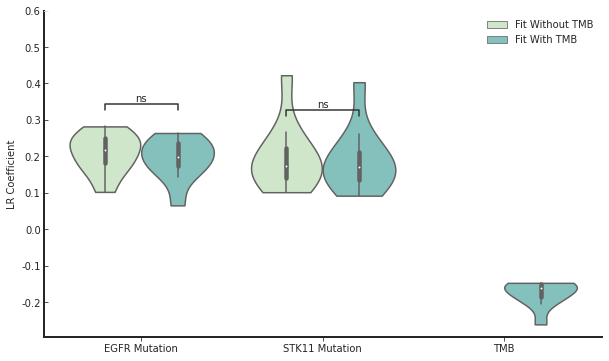

In [32]:
generate_genomic_lr_fig(df_genomic, df_outcomes)
plt.savefig('vector_figs/4B.svg', bbox_inches='tight')

print ("EGFR-STK11", pearsonr_ci(df_genomic['EGFR driver_binarized'], df_genomic['STK11 driver_binarized']))
print ("EGFR-STK11", pearsonr_ci(df_genomic['EGFR driver_binarized'], df_genomic['TMB']))

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica


AUC 0.383 +/- 0.083 95% CL: [TMB                 ] 
AUC 0.481 +/- 0.028 95% CL: [MET Amplification   ] 
AUC 0.527 +/- 0.016 95% CL: [EGFR Amplification  ] 
AUC 0.497 +/- 0.025 95% CL: [BRAF Mutation       ] 
AUC 0.479 +/- 0.037 95% CL: [MET Mutation        ] 
AUC 0.519 +/- 0.034 95% CL: [ERBB2 Mutation      ] 
AUC 0.511 +/- 0.033 95% CL: [ARID1A Mutation     ] 
AUC 0.516 +/- 0.013 95% CL: [ERBB2 Amplification ] 
AUC 0.565 +/- 0.045 95% CL: [STK11 Mutation      ] 
AUC 0.559 +/- 0.023 95% CL: [EGFR Mutation       ] 
4A


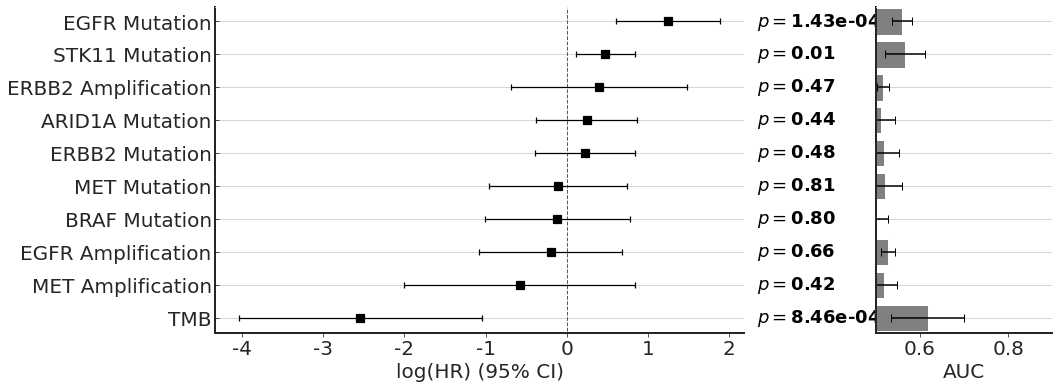

In [33]:
importlib.reload(lung_helpers)
from lung_helpers import *

df_genomic_for_cox = df_genomic.drop(columns="RET: AMP_binarized")
df_genomic_for_cox.columns = [col.replace("driver_binarized", "Mutation").replace(": AMP_binarized", " Amplification") for col in df_genomic_for_cox.columns]

generate_cox_plot_V2(
    [df_genomic_for_cox], 
    df_clinical.loc[df_genomic.index],
     label_map={
        'risk_rad_lesion_pc': 'Parenchymal Lesion Risk',
        'risk_rad_lesion_pl': 'Pleural Lesion Risk',
        'risk_rad_lesion_ln': 'Nodal Lesion Risk',
        'risk_path_ihc_pdl1': 'IHC-A Risk',
        'risk_gen_driver_mut_amp': 'Genomic Risk',
        'risk_cnl_pdl1_score': 'PDL1-TPS Risk',
        'score': 'Overall Score'
    },
    panel='4A')

plt.savefig('vector_figs/4A.svg', bbox_inches='tight')

In [34]:
import statannotations
import statannotations.Annotator
import statannotations.format_annotations

importlib.reload(statannotations)
importlib.reload(statannotations.Annotator)
importlib.reload(statannotations.format_annotations)


<module 'statannotations.format_annotations' from 'C:\\Users\\Admin\\miniconda3\\envs\\doan-env\\lib\\site-packages\\statannotations\\format_annotations.py'>

            PD-L1 TPS Score   TMB  Num. Lesions
main_index                                     
P-0000239               NaN   4.0           1.0
P-0000302               NaN   1.0           2.0
P-0001987              80.0  26.0           NaN
P-0002485               5.0   3.0           1.0
P-0002794              70.0   1.0           1.0
...                     ...   ...           ...
P-0035638               0.0  13.0           1.0
P-0039832              95.0  12.0           4.0
P-0040848              80.0   5.0           NaN
P-0044186               5.0  12.0           NaN
P-0045298               0.0  29.0           2.0

[247 rows x 3 columns]
201
    Outcome          Feature  PD-L1 TPS Score
0     PR/CR  PD-L1 TPS Score             80.0
1     SD/PD  PD-L1 TPS Score              5.0
2     PR/CR  PD-L1 TPS Score             70.0
3     PR/CR  PD-L1 TPS Score             70.0
4     SD/PD  PD-L1 TPS Score              0.0
..      ...              ...              ...
196   SD/PD  PD-L1 TPS Sco

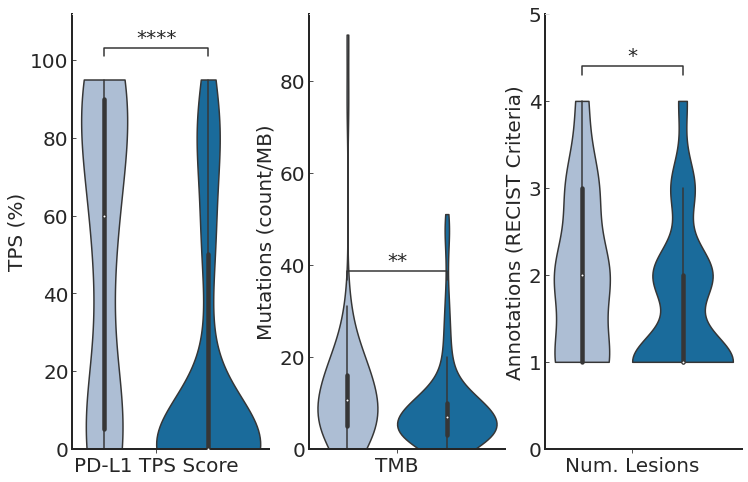

In [35]:
importlib.reload(lung_helpers)
from lung_helpers import *

make_general_violin_plot(df_pdl1.rename(columns={'Sauter PD-L1 Score':'PD-L1 TPS Score'}).join(df_tmb, how='outer').join(df_radiology[df_radiology['job_tag']=='filtered-radiomics'].groupby('main_index').size().rename('Num. Lesions')), df_clinical, ylims=(0, None), units=['TPS (%)', 'Mutations (count/MB)', 'Annotations (RECIST Criteria)'])
plt.savefig('vector_figs/1D.svg', bbox_inches='tight')

MultiIndex([('P-0000239',  'unfiltered-radiomics', 'PC'),
            ('P-0000239',    'filtered-radiomics', 'PC'),
            ('P-0000239', 'pertubation-radiomics', 'PC'),
            ('P-0000239', 'pertubation-radiomics', 'PC'),
            ('P-0000239', 'pertubation-radiomics', 'PC'),
            ('P-0000239', 'pertubation-radiomics', 'PC'),
            ('P-0000239', 'pertubation-radiomics', 'PC'),
            ('P-0000239', 'pertubation-radiomics', 'PC'),
            ('P-0000239', 'pertubation-radiomics', 'PC'),
            ('P-0000239', 'pertubation-radiomics', 'PC'),
            ...
            ('P-0039832', 'pertubation-radiomics', 'LN'),
            ('P-0039832', 'pertubation-radiomics', 'LN'),
            ('P-0039832', 'pertubation-radiomics', 'LN'),
            ('P-0039832', 'pertubation-radiomics', 'LN'),
            ('P-0039832', 'pertubation-radiomics', 'LN'),
            ('P-0039832', 'pertubation-radiomics', 'LN'),
            ('P-0039832', 'pertubation-radiomics', 'LN')

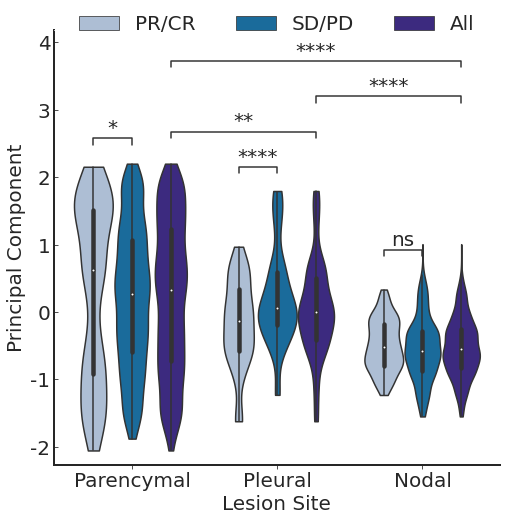

In [36]:
importlib.reload(lung_helpers)
from lung_helpers import *
generate_pca_figure_V2(df_radiology_by_site, df_clinical)
plt.savefig('vector_figs/2C.svg', bbox_inches='tight')

PC        original_shape_MeshVolume  original_shape_MajorAxisLength  \
count                 204.000000                      204.000000   
mean                24320.225082                       35.052064   
std                 57220.702015                       22.509275   
min                   145.500000                        7.446478   
25%                  1547.875000                       19.100568   
50%                  4794.604167                       27.404560   
75%                 21218.739583                       45.582755   
max                504772.583333                      134.207608   

       original_shape_MinorAxisLength  original_shape_Sphericity  
count                      204.000000                 204.000000  
mean                        24.687551                   0.693046  
std                         15.600327                   0.092762  
min                          5.438878                   0.401544  
25%                         13.714305            

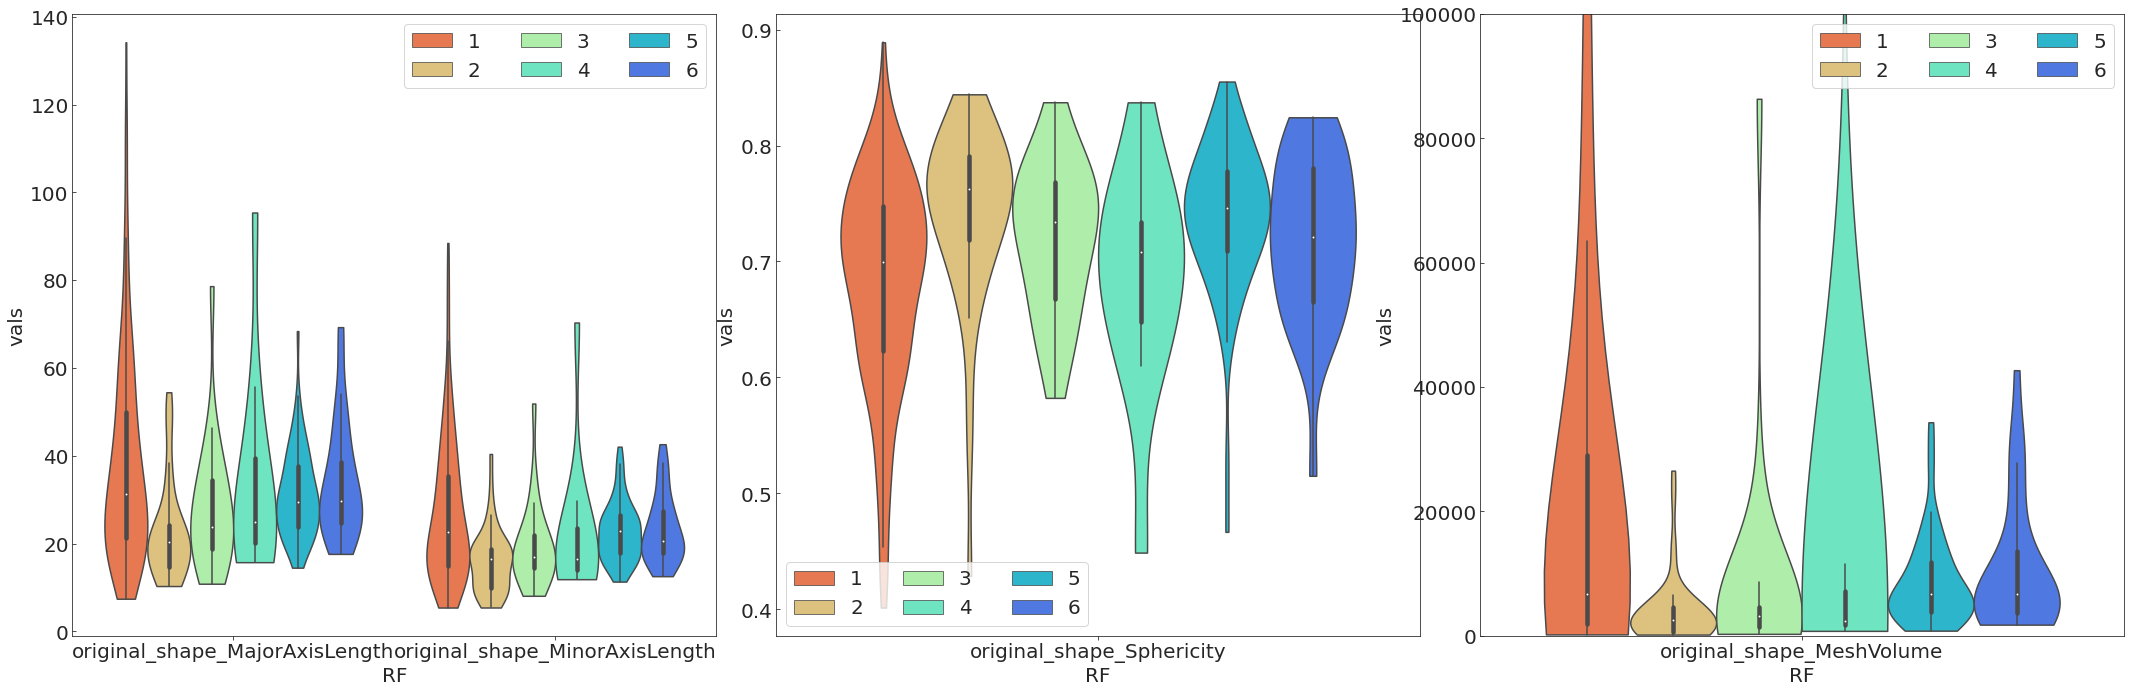

In [37]:
importlib.reload(lung_helpers)
from lung_helpers import *
make_rad_violin_plots(df_radiology)

In [38]:
df_glcm.join(df_clinical)['Outcome'].value_counts()

SD/PD    63
PR/CR    42
Name: Outcome, dtype: int64

     Outcome    PD-L1 Quantification Feature  Normalized Value [A.U.]
0      PR/CR  PD-L1 Pixel Intensity skewness                -0.761375
1      SD/PD  PD-L1 Pixel Intensity skewness                 1.937251
2      PR/CR  PD-L1 Pixel Intensity skewness                 0.617399
3      SD/PD  PD-L1 Pixel Intensity skewness                 0.445182
4      SD/PD  PD-L1 Pixel Intensity skewness                 1.183338
...      ...                             ...                      ...
2620   SD/PD             SumSquares skewness                 0.109551
2621   SD/PD             SumSquares skewness                -0.615407
2622   PR/CR             SumSquares skewness                -0.760074
2623   SD/PD             SumSquares skewness                -0.786852
2624   PR/CR             SumSquares skewness                -0.892766

[2625 rows x 3 columns]
0.3810831089485771


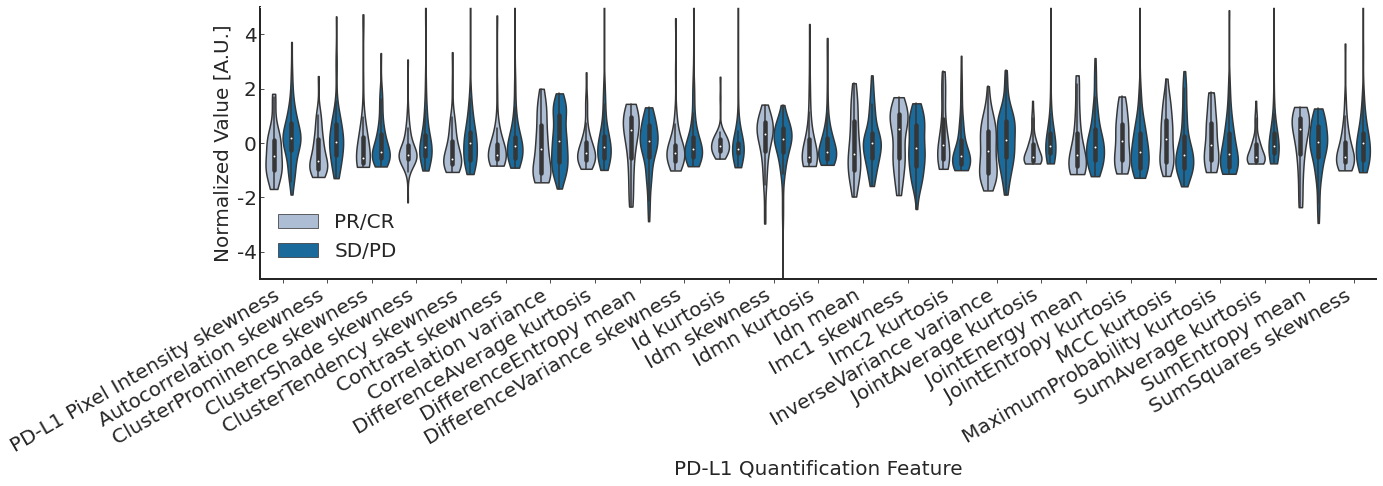

In [39]:
importlib.reload(lung_helpers)
from lung_helpers import *
fx_to_show = get_best_glcm(df_glcm, df_clinical)
make_path_violin_plots(df_glcm[fx_to_show], df_clinical, ylims=None)
plt.savefig('vector_figs/3B-new.svg', bbox_inches='tight')

          TPS Category               variable     value
0       Low\n[1%, 25%]  PD-L1 Pixel Intensity -0.432067
1    High\n[75%, 100%]  PD-L1 Pixel Intensity  1.376057
2    High\n[75%, 100%]  PD-L1 Pixel Intensity  1.042702
3    High\n[75%, 100%]  PD-L1 Pixel Intensity  1.217134
4    High\n[75%, 100%]  PD-L1 Pixel Intensity  1.737379
..                 ...                    ...       ...
799  High\n[75%, 100%]          Imc2 Kurtosis       NaN
800               Zero          Imc2 Kurtosis       NaN
801               Zero          Imc2 Kurtosis       NaN
802  High\n[75%, 100%]          Imc2 Kurtosis       NaN
803               Zero          Imc2 Kurtosis       NaN

[804 rows x 3 columns]


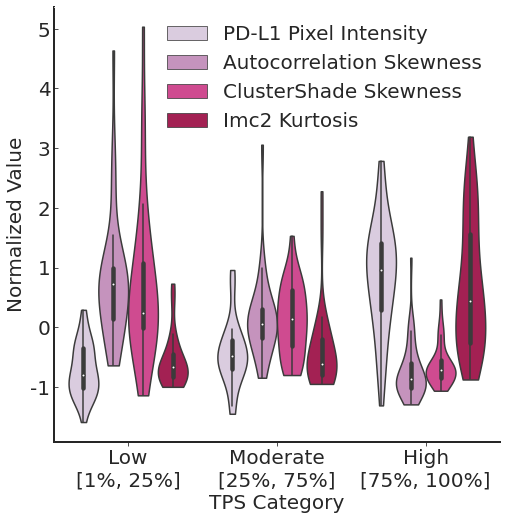

In [40]:
importlib.reload(lung_helpers)
from lung_helpers import *

make_ihc_vs_pdl1_plot_V2(
    df_pdl1, 
    df_glcm, 
    ['original_pixels_channel_1_mean', 'original_glcm_Autocorrelation_channel_1_skewness', 'original_glcm_ClusterTendency_channel_1_skewness', 'original_glcm_Imc2_channel_1_kurtosis'], 
    ['PD-L1 Pixel Intensity', 'Autocorrelation Skewness', r'ClusterShade Skewness', r'Imc2 Kurtosis'], 
    sns.color_palette("PuRd", 4), ylabel='Normalized Value')
plt.savefig('vector_figs/3D.svg', bbox_inches='tight')

In [41]:
df_models = []
for key in summary_dfs:    
    if "fold" in summary_dfs[key].columns:
        df_model = summary_dfs[key][['score', 'fold', 'label']]
    else:
        df_model = summary_dfs[key][['score', 'label']]

    df_models.append ( df_model.rename(columns={'score':key+' score',  'fold':key+' fold', 'label':key+' label'}) )
pd.concat(df_models, axis=1).to_excel(f'./excel/EF1.xlsx')

df_models_ss = []
for key in summary_dfs_ss:
    df_model = pd.concat ( [pd.DataFrame([summary_dfs_ss[key][fold][2], summary_dfs_ss[key][fold][3], [fold+1]*len(summary_dfs_ss[key][0][3])], index=[key + ' score', key + ' label', key + ' fold']).T for fold in range(len(summary_dfs_ss[key]))])
    df_models_ss.append(df_model.reset_index())
pd.concat(df_models_ss, axis=1, ignore_index=True).to_excel(f'./excel/EF2.xlsx')

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica


 >>> LR Rad-PC, AUC=0.64, 95% CI 0.54-0.74
 >>> LR Rad-LN, AUC=0.68, 95% CI 0.55-0.81


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica


 >>> LR Rad-Average, AUC=0.66, 95% CI 0.57-0.74
 >>> MILR Rad-Lesions, AUC=0.61, 95% CI 0.52-0.70
 >>> LR Rad-PC-Valid, AUC=0.66, 95% CI 0.48-0.84
 >>> LR Rad-LN-Valid, AUC=0.32, 95% CI 0.06-0.57
 >>> LR Rad-Average-Valid, AUC=0.52, 95% CI 0.34-0.70
 >>> MILR Rad-Lesions-Valid, AUC=0.66, 95% CI 0.45-0.86
2D
                    model       auc  auc_upper_95CI  auc_lower_95CI
0               LR Rad-PC  0.640698        0.736925        0.544470
1               LR Rad-LN  0.681202        0.811746        0.550657
2          LR Rad-Average  0.655709        0.739877        0.571542
3        MILR Rad-Lesions  0.611664        0.702234        0.521094
4         LR Rad-PC-Valid  0.663082        0.841803        0.484362
5         LR Rad-LN-Valid  0.317647        0.570765        0.064529
6    LR Rad-Average-Valid  0.522222        0.704525        0.339919
7  MILR Rad-Lesions-Valid  0.655556        0.857732        0.453379
 >>> LR IHC-A, AUC=0.62, 95% CI 0.51-0.74
 >>> LR IHC-G, AUC=0.63, 95% CI 0.52-

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica


 >>> LR Multimodal-Average, AUC=0.73, 95% CI 0.66-0.80
5C
                      model       auc  auc_upper_95CI  auc_lower_95CI  \
0               LR Clinical  0.569517        0.658437        0.480597   
1                 LR Rad-PC  0.640698        0.736925        0.544470   
2                 LR Rad-LN  0.681202        0.811746        0.550657   
3            LR Rad-Average  0.655709        0.739877        0.571542   
4          MILR Rad-Lesions  0.611664        0.702234        0.521094   
5                  LR IHC-A  0.624339        0.736626        0.512052   
6                  LR IHC-G  0.633787        0.744483        0.523090   
7               LR PDL1-TPS  0.729284        0.811443        0.647124   
8         LR Path-A-Average  0.695117        0.787964        0.602271   
9         LR Path-G-Average  0.694225        0.786271        0.602179   
10          LR Gen-Only-TMB  0.613252        0.698863        0.527641   
11            LR Gen-No-TMB  0.605100        0.682605        0.527

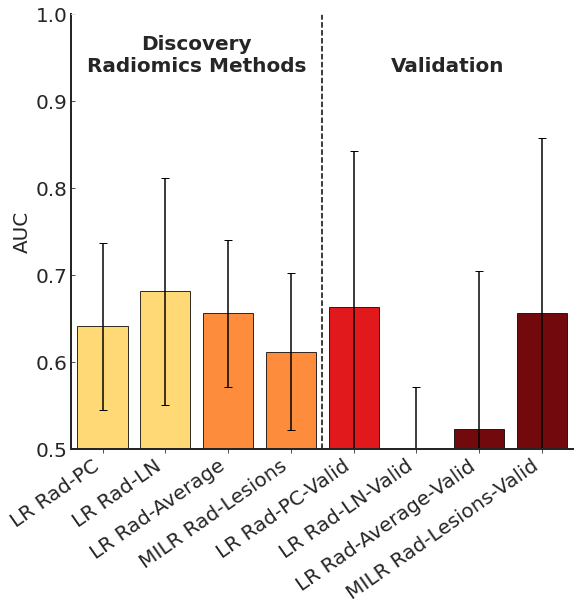

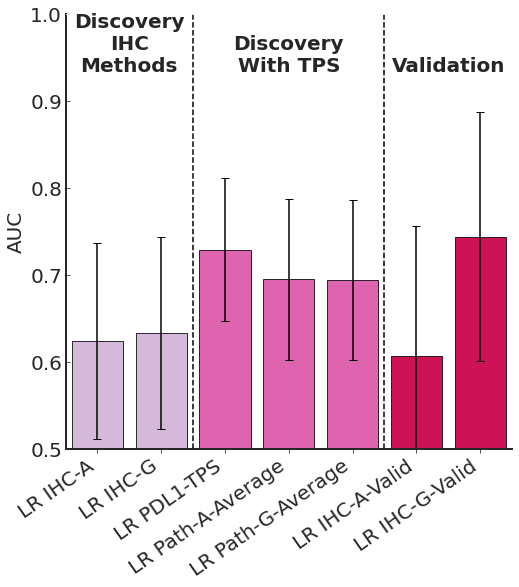

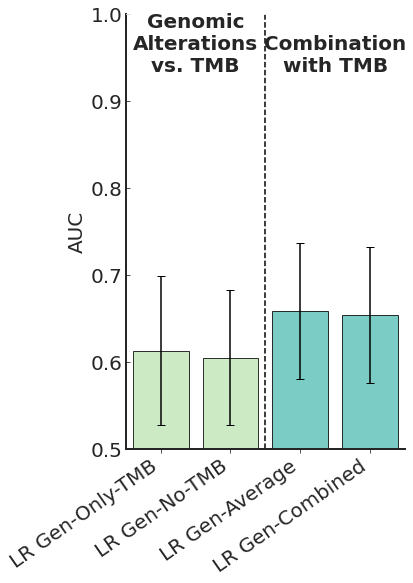

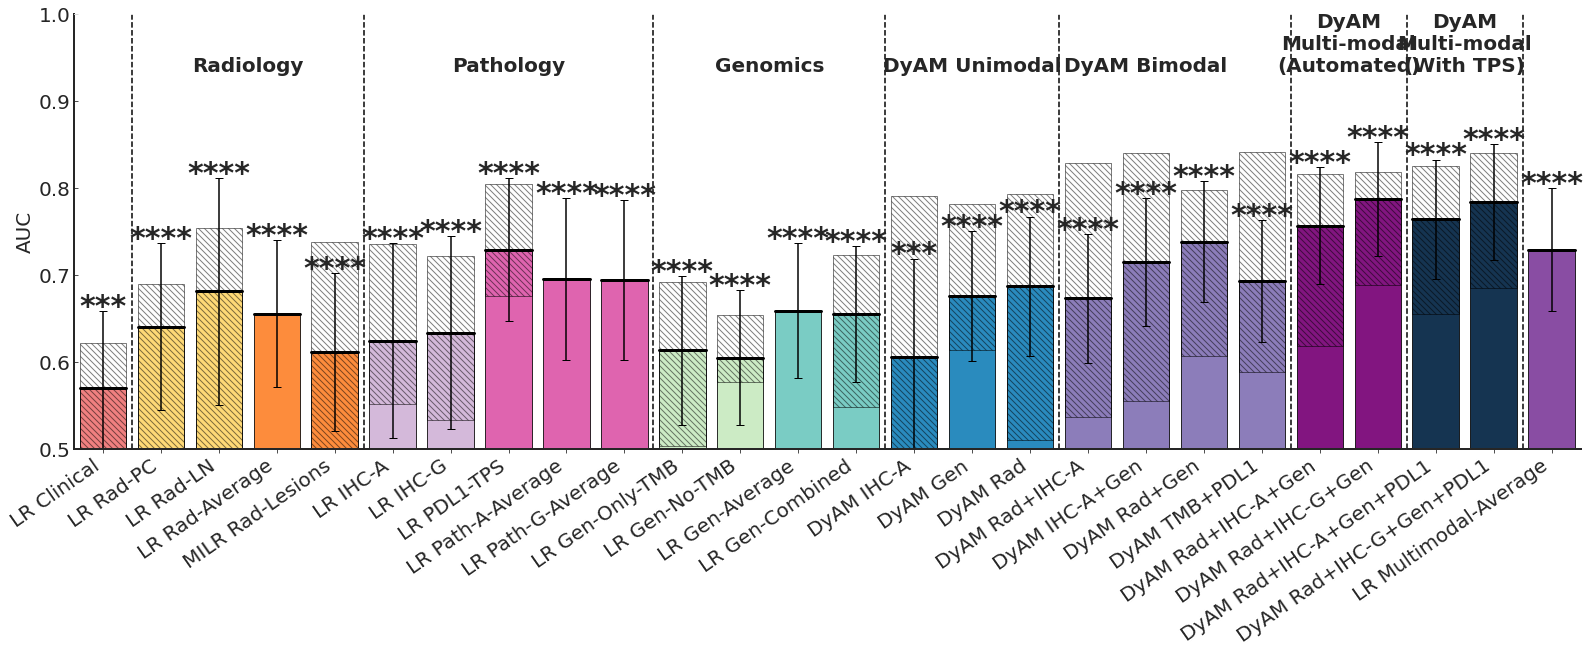

In [42]:
importlib.reload(lung_helpers)
from lung_helpers import *

rad_colors = sns.color_palette("YlOrRd", 3)

path_colors = sns.color_palette("PuRd", 3)

genomic_colors = sns.color_palette("GnBu", 3)

DyAM_colors = sns.color_palette("BuPu", 6)

cln_models = ['LR Clinical']
rad_train_models  = ['LR Rad-PC', 'LR Rad-LN', 'LR Rad-Average', 'MILR Rad-Lesions']
rad_valid_models  = ['LR Rad-PC-Valid','LR Rad-LN-Valid', 'LR Rad-Average-Valid', 'MILR Rad-Lesions-Valid']

path_train_models = ['LR IHC-A', 'LR IHC-G', 'LR PDL1-TPS', 'LR Path-A-Average', 'LR Path-G-Average']
path_valid_models = ['LR IHC-A-Valid', 'LR IHC-G-Valid']

genomic_train_models = ['LR Gen-Only-TMB', 'LR Gen-No-TMB', 'LR Gen-Average', 'LR Gen-Combined']

DyAM_models = ['DyAM IHC-A', 'DyAM Gen','DyAM Rad', 
               'DyAM Rad+IHC-A', 'DyAM IHC-A+Gen', 'DyAM Rad+Gen', 'DyAM TMB+PDL1', 
               'DyAM Rad+IHC-A+Gen', 'DyAM Rad+IHC-G+Gen',
               'DyAM Rad+IHC-A+Gen+PDL1', 'DyAM Rad+IHC-G+Gen+PDL1',
               'LR Multimodal-Average', ]

annot_list_rad_old = [
    {'name':'Discovery\nSite-wise LR', 'left':'LR Rad-PC', 'right':'LR Rad-LN'},
    {'name':'Discovery\nCombined LR', 'left':'LR Rad-Average', 'right':'MILR Rad-Lesions'},
    {'name':'Validation\nSite-wise LR', 'left':'LR Rad-PC-Valid', 'right':'LR Rad-LN-Valid'},
    {'name':'Validation\nCombined LR', 'left':'LR Rad-Average-Valid', 'right':'MILR Rad-Lesions-Valid'},
]
annot_list_rad = [
    {'name':'Discovery\nRadiomics Methods', 'left':'LR Rad-PC', 'right':'MILR Rad-Lesions'},
    {'name':'Validation', 'left':'LR Rad-PC-Valid', 'right':'MILR Rad-Lesions-Valid'},
]
annot_list_path = [
    {'name':'Discovery\nIHC\nMethods', 'left':'LR IHC-A', 'right':'LR IHC-G'},
    {'name':'Discovery\nWith TPS', 'left':'LR PDL1-TPS', 'right':'LR Path-G-Average'},
    {'name':'Validation', 'left':'LR IHC-A-Valid', 'right':'LR IHC-G-Valid'},
]
annot_list_gen = [
    {'name':'Genomic\nAlterations\nvs. TMB', 'left':'LR Gen-Only-TMB', 'right':'LR Gen-No-TMB'},
    {'name':'Combination\nwith TMB', 'left':'LR Gen-Average', 'right':'LR Gen-Combined'},
]

annot_list = [
    {'name':'Radiology', 'left':'LR Rad-PC', 'right':'MILR Rad-Lesions'},
    {'name':'Pathology', 'left':'LR IHC-A', 'right':'LR Path-G-Average'},
    {'name':'Genomics',  'left':'LR Gen-Only-TMB', 'right':'LR Gen-Combined'},
    {'name':'DyAM Unimodal',  'left':'DyAM IHC-A', 'right':'DyAM Rad'},
    {'name':'DyAM Bimodal',  'left':'DyAM Rad+IHC-A', 'right':'DyAM Rad+Gen'},
    {'name':'DyAM\nMulti-modal\n(Automated)',  'left':'DyAM Rad+IHC-A+Gen', 'right':'DyAM Rad+IHC-G+Gen'},  
    {'name':'DyAM\nMulti-modal\n(With TPS)',  'left':'DyAM Rad+IHC-A+Gen+PDL1', 'right':'DyAM Rad+IHC-G+Gen+PDL1'},  
    {'name':'',  'left':'LR Multimodal-Average', 'right':'LR Multimodal-Average'},  
]

model_dict = {
    'LR Clinical': {'color': CSS4_COLORS['lightcoral']},
    
    'LR Rad-PC': {'color': rad_colors[0]},
    'LR Rad-PL': {'color': rad_colors[0]},
    'LR Rad-LN': {'color': rad_colors[0]},
    'LR Rad-Average': {'color': rad_colors[1]},

    'MILR Rad-Lesions': {'color': rad_colors[1]},

    'LR Rad-PC-Valid': {'color': rad_colors[2]},
    'LR Rad-PL-Valid': {'color': rad_colors[2]},
    'LR Rad-LN-Valid': {'color': rad_colors[2]},
    'LR Rad-Average-Valid': {'color':  '#71090D'},

    'MILR Rad-Lesions-Valid': {'color': '#71090D'},
    
    'LR IHC-A': {'color': path_colors[0]},
    'LR IHC-S': {'color': path_colors[0]},
    'LR IHC-G': {'color': path_colors[0]},
    'LR PDL1-TPS': {'color': path_colors[1]},
    'LR Path-A-Average': {'color': path_colors[1]},
    'LR Path-G-Average': {'color': path_colors[1]},

    'LR IHC-A-Valid': {'color': path_colors[2]},
    'LR IHC-S-Valid': {'color': path_colors[2]},
    'LR IHC-G-Valid': {'color': path_colors[2]},
    
    'LR Gen-Only-TMB': {'color': genomic_colors[0]},
    'LR Gen-No-TMB':   {'color': genomic_colors[0]},
    'LR Gen-Average':  {'color': genomic_colors[1]},
    'LR Gen-Combined':  {'color': genomic_colors[1]},

    'DyAM TMB': {'color': '#FDDF21'},
    'DyAM PDL1': {'color': '#FDDF21'},
    'DyAM TMB+PDL1': {'color': DyAM_colors[3]},#'#CAAF02'},
    
    'DyAM Rad': {'color': genomic_colors[2]},
    'DyAM IHC-A': {'color': genomic_colors[2]},
    'DyAM Gen': {'color': genomic_colors[2]},
    
    'DyAM Rad+IHC-A': {'color': DyAM_colors[3]},
    'DyAM IHC-A+Gen': {'color': DyAM_colors[3]},
    'DyAM Rad+Gen':   {'color': DyAM_colors[3]},

    'DyAM Rad+IHC-A+Gen': {'color': DyAM_colors[5]},
    'DyAM Rad+IHC-S+Gen': {'color': DyAM_colors[5]},
    'DyAM Rad+IHC-G+Gen': {'color': DyAM_colors[5]},
    'DyAM Rad+PDL1+Gen': {'color': DyAM_colors[5]},
    
    'LR Multimodal-Average' : {'color': DyAM_colors[4]},
    
    'DyAM PC+IHC-S+MutAmp+PDL1' : {'color': DyAM_colors[4]},

    'DyAM Rad+IHC-A+Gen+PDL1': {'color': '#153451'},
    'DyAM Rad+IHC-S+Gen+PDL1': {'color': '#153451'},
    'DyAM Rad+IHC-G+Gen+PDL1': {'color': '#153451'},
}

generate_auc_plot_V2(summary_dfs,  models=filter_dict(model_dict, rad_train_models + rad_valid_models), annot_list=annot_list_rad, panel='2D')
plt.savefig('vector_figs/2D.svg', bbox_inches='tight')

generate_auc_plot_V2(summary_dfs,  models=filter_dict(model_dict, path_train_models + path_valid_models), annot_list=annot_list_path, panel='3E')
plt.savefig('vector_figs/3E.svg', bbox_inches='tight')

generate_auc_plot_V2(summary_dfs,  models=filter_dict(model_dict, genomic_train_models), annot_list=annot_list_gen, panel='4C')
plt.savefig('vector_figs/4C.svg', bbox_inches='tight')

generate_auc_plot_V2(summary_dfs,  
    models=filter_dict(model_dict, cln_models + rad_train_models + path_train_models + genomic_train_models + DyAM_models), 
    annot_list=annot_list, show_errors=True, ss_aucs=summary_dfs_ss, panel='5C')
plt.savefig('vector_figs/4D.svg', bbox_inches='tight')



 >>> LR Clinical, F1-score=0.68
 >>> LR Rad-PC, F1-score=0.74
 >>> LR Rad-LN, F1-score=0.70
 >>> LR Rad-Average, F1-score=0.73
 >>> MILR Rad-Lesions, F1-score=0.67
 >>> LR IHC-A, F1-score=0.67
 >>> LR IHC-G, F1-score=0.67
 >>> LR PDL1-TPS, F1-score=0.79
 >>> LR Path-A-Average, F1-score=0.80
 >>> LR Path-G-Average, F1-score=0.81
 >>> LR Gen-Only-TMB, F1-score=0.80
 >>> LR Gen-No-TMB, F1-score=0.49
 >>> LR Gen-Average, F1-score=0.76
 >>> LR Gen-Combined, F1-score=0.77
 >>> DyAM IHC-A, F1-score=0.66
 >>> DyAM Gen, F1-score=0.72
 >>> DyAM Rad, F1-score=0.76
 >>> DyAM Rad+IHC-A, F1-score=0.77
 >>> DyAM IHC-A+Gen, F1-score=0.78
 >>> DyAM Rad+Gen, F1-score=0.78
 >>> DyAM TMB+PDL1, F1-score=0.75
 >>> DyAM Rad+IHC-A+Gen, F1-score=0.79
 >>> DyAM Rad+IHC-G+Gen, F1-score=0.81
 >>> DyAM Rad+IHC-A+Gen+PDL1, F1-score=0.81
 >>> DyAM Rad+IHC-G+Gen+PDL1, F1-score=0.82
 >>> LR Multimodal-Average, F1-score=0.79
                      Model  F1-score
0               LR Clinical  0.680982
1                 L

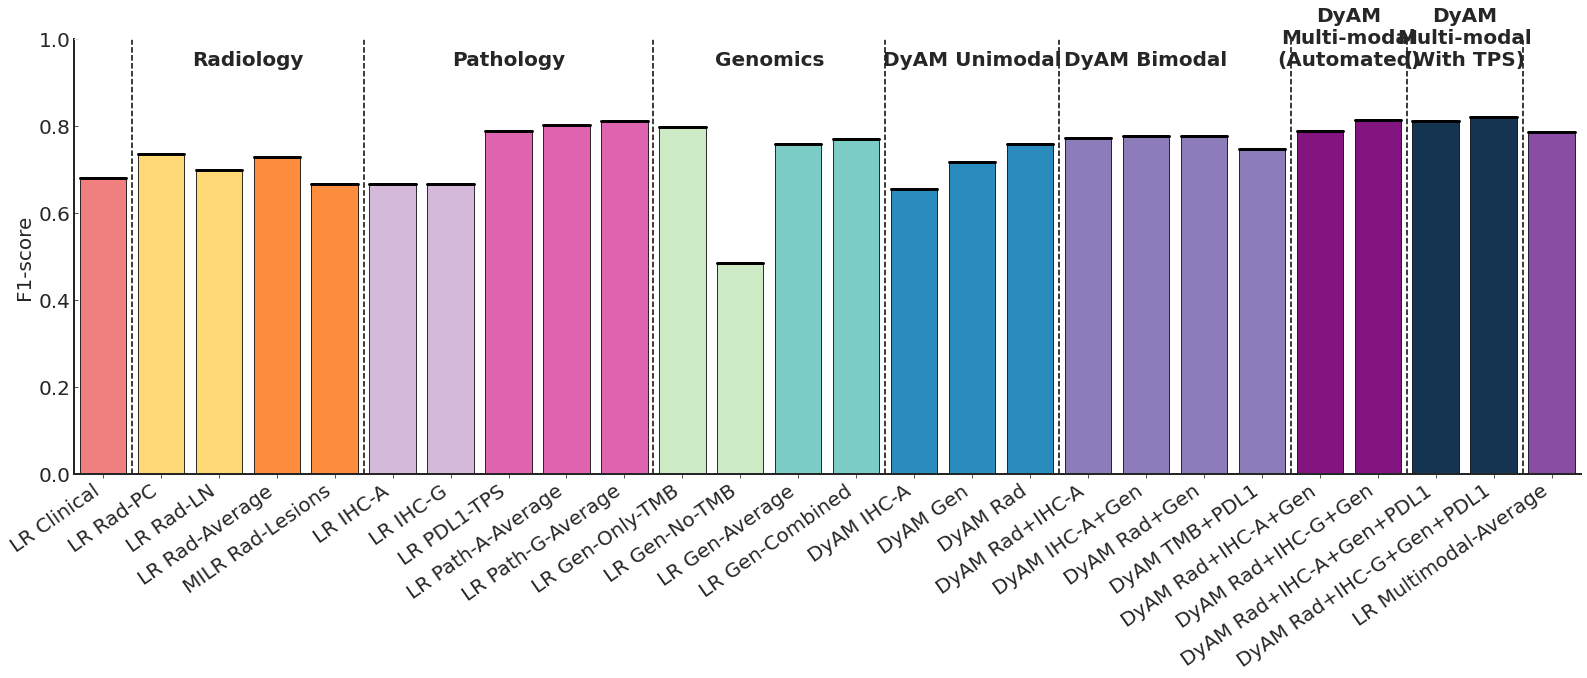

 >>> LR Clinical, Precision Score=0.79
 >>> LR Rad-PC, Precision Score=0.81
 >>> LR Rad-LN, Precision Score=0.76
 >>> LR Rad-Average, Precision Score=0.81
 >>> MILR Rad-Lesions, Precision Score=0.77
 >>> LR IHC-A, Precision Score=0.70
 >>> LR IHC-G, Precision Score=0.72
 >>> LR PDL1-TPS, Precision Score=0.84
 >>> LR Path-A-Average, Precision Score=0.84
 >>> LR Path-G-Average, Precision Score=0.84
 >>> LR Gen-Only-TMB, Precision Score=0.81
 >>> LR Gen-No-TMB, Precision Score=0.92
 >>> LR Gen-Average, Precision Score=0.83
 >>> LR Gen-Combined, Precision Score=0.81
 >>> DyAM IHC-A, Precision Score=0.70
 >>> DyAM Gen, Precision Score=0.85
 >>> DyAM Rad, Precision Score=0.78
 >>> DyAM Rad+IHC-A, Precision Score=0.83
 >>> DyAM IHC-A+Gen, Precision Score=0.86
 >>> DyAM Rad+Gen, Precision Score=0.85
 >>> DyAM TMB+PDL1, Precision Score=0.83
 >>> DyAM Rad+IHC-A+Gen, Precision Score=0.86
 >>> DyAM Rad+IHC-G+Gen, Precision Score=0.88
 >>> DyAM Rad+IHC-A+Gen+PDL1, Precision Score=0.88
 >>> DyAM Rad

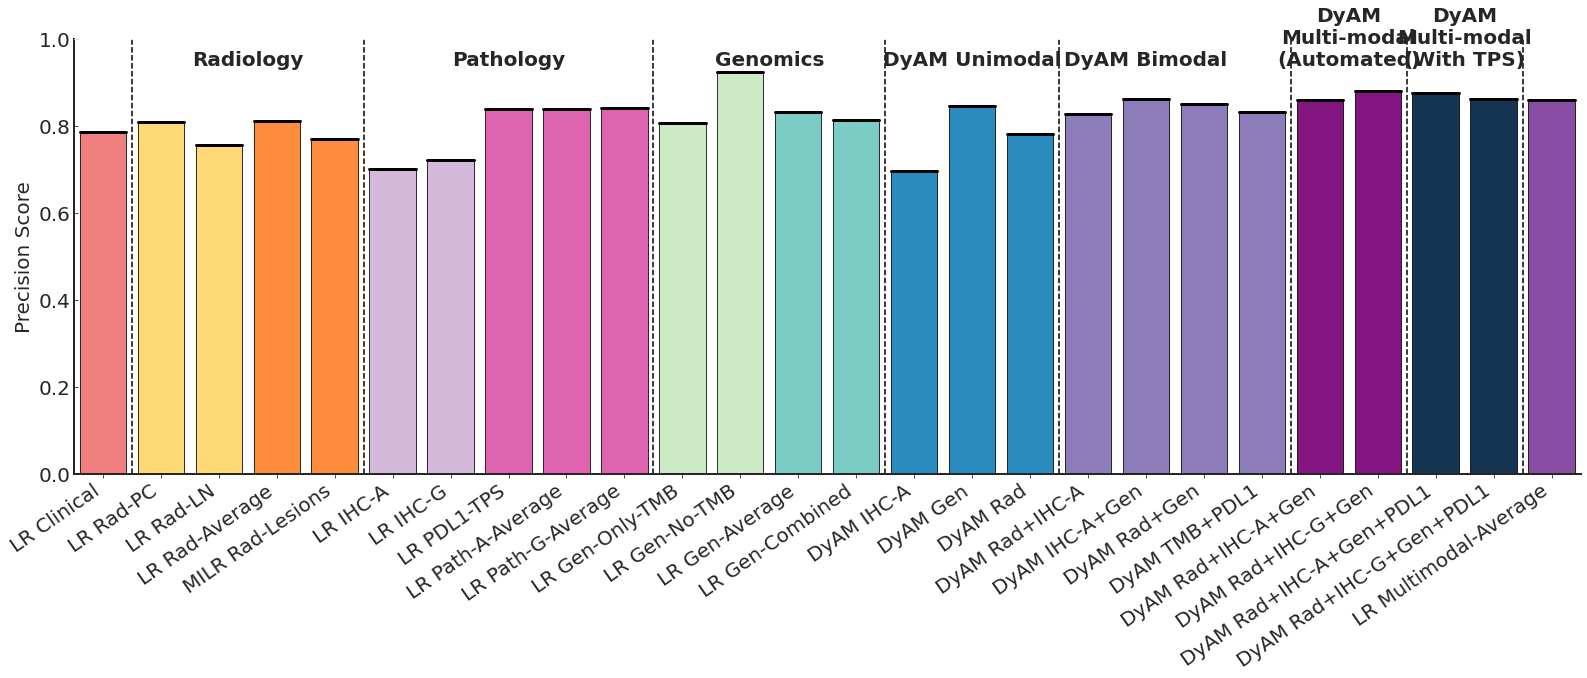

 >>> LR Clinical, Recall Score=0.60
 >>> LR Rad-PC, Recall Score=0.68
 >>> LR Rad-LN, Recall Score=0.65
 >>> LR Rad-Average, Recall Score=0.66
 >>> MILR Rad-Lesions, Recall Score=0.59
 >>> LR IHC-A, Recall Score=0.63
 >>> LR IHC-G, Recall Score=0.62
 >>> LR PDL1-TPS, Recall Score=0.74
 >>> LR Path-A-Average, Recall Score=0.77
 >>> LR Path-G-Average, Recall Score=0.78
 >>> LR Gen-Only-TMB, Recall Score=0.79
 >>> LR Gen-No-TMB, Recall Score=0.33
 >>> LR Gen-Average, Recall Score=0.70
 >>> LR Gen-Combined, Recall Score=0.73
 >>> DyAM IHC-A, Recall Score=0.62
 >>> DyAM Gen, Recall Score=0.62
 >>> DyAM Rad, Recall Score=0.74
 >>> DyAM Rad+IHC-A, Recall Score=0.73
 >>> DyAM IHC-A+Gen, Recall Score=0.71
 >>> DyAM Rad+Gen, Recall Score=0.71
 >>> DyAM TMB+PDL1, Recall Score=0.68
 >>> DyAM Rad+IHC-A+Gen, Recall Score=0.73
 >>> DyAM Rad+IHC-G+Gen, Recall Score=0.76
 >>> DyAM Rad+IHC-A+Gen+PDL1, Recall Score=0.76
 >>> DyAM Rad+IHC-G+Gen+PDL1, Recall Score=0.78
 >>> LR Multimodal-Average, Recall Sc

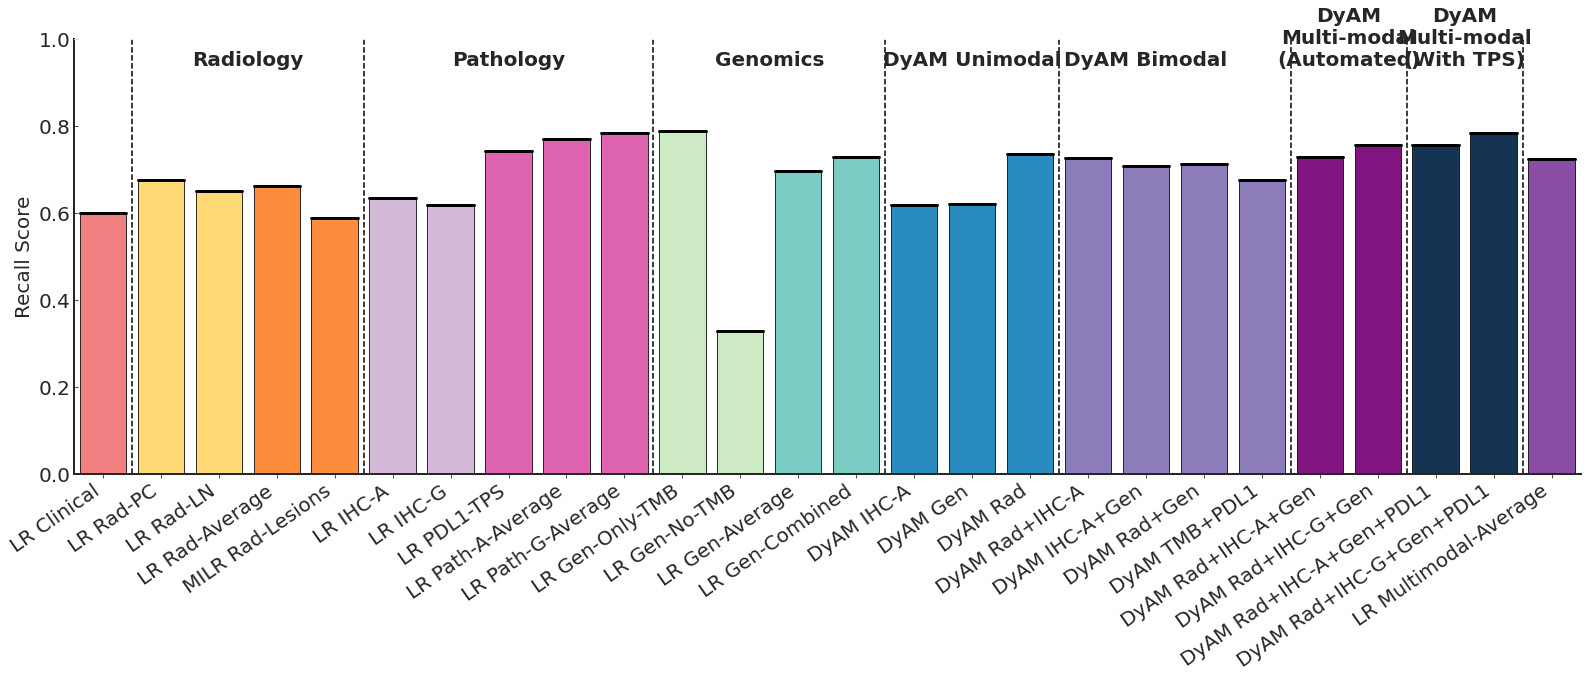

 >>> LR Clinical, AUC=0.57
 >>> LR Rad-PC, AUC=0.64
 >>> LR Rad-LN, AUC=0.68
 >>> LR Rad-Average, AUC=0.66
 >>> MILR Rad-Lesions, AUC=0.61
 >>> LR IHC-A, AUC=0.62
 >>> LR IHC-G, AUC=0.63
 >>> LR PDL1-TPS, AUC=0.73
 >>> LR Path-A-Average, AUC=0.70
 >>> LR Path-G-Average, AUC=0.69
 >>> LR Gen-Only-TMB, AUC=0.61
 >>> LR Gen-No-TMB, AUC=0.61
 >>> LR Gen-Average, AUC=0.66
 >>> LR Gen-Combined, AUC=0.65
 >>> DyAM IHC-A, AUC=0.61
 >>> DyAM Gen, AUC=0.68
 >>> DyAM Rad, AUC=0.69
 >>> DyAM Rad+IHC-A, AUC=0.67
 >>> DyAM IHC-A+Gen, AUC=0.71
 >>> DyAM Rad+Gen, AUC=0.74
 >>> DyAM TMB+PDL1, AUC=0.69
 >>> DyAM Rad+IHC-A+Gen, AUC=0.76
 >>> DyAM Rad+IHC-G+Gen, AUC=0.79
 >>> DyAM Rad+IHC-A+Gen+PDL1, AUC=0.76
 >>> DyAM Rad+IHC-G+Gen+PDL1, AUC=0.78
 >>> LR Multimodal-Average, AUC=0.73
                      Model  F1-score  Precision Score  Recall Score       AUC
0               LR Clinical  0.680982         0.787234      0.600000  0.569517
1                 LR Rad-PC  0.736364         0.810000      0.67500

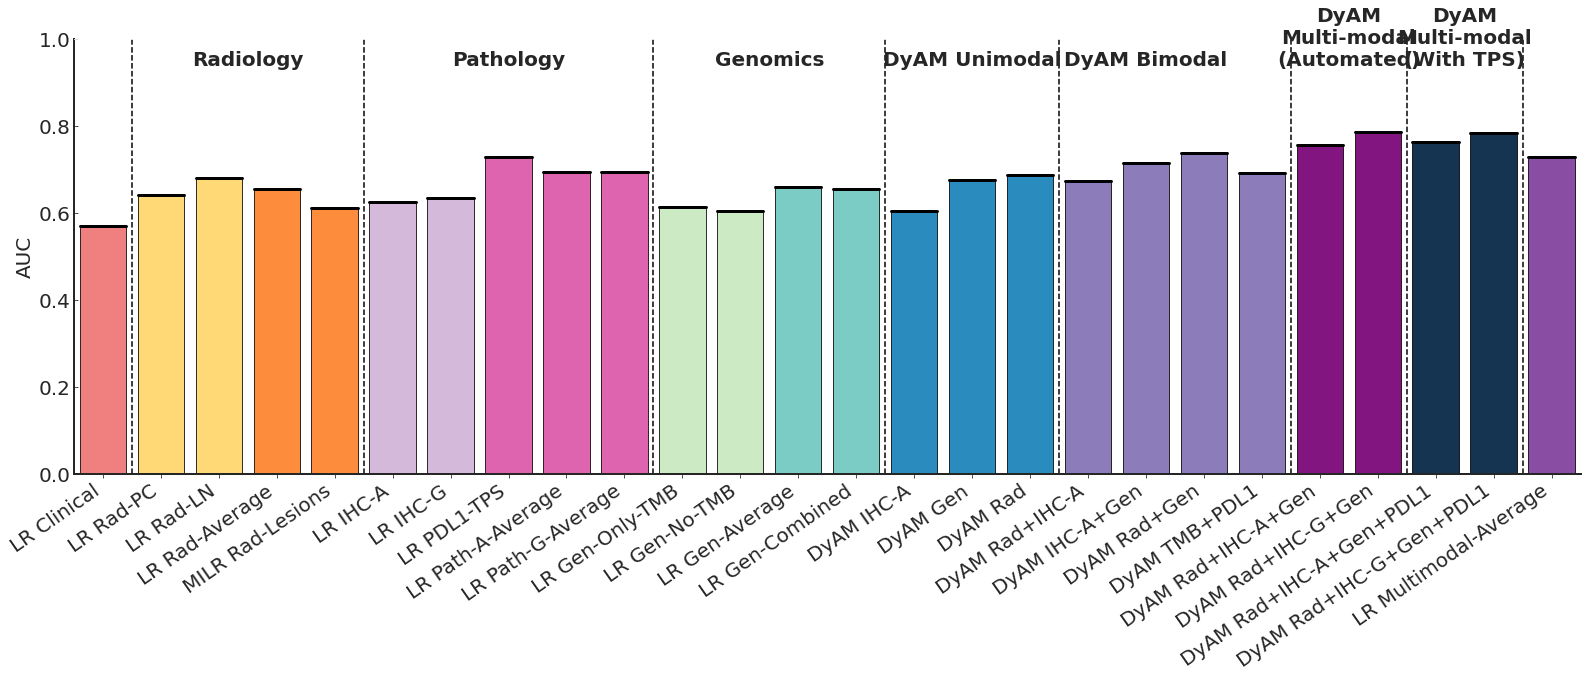

 >>> LR Clinical, Accuracy=0.58
 >>> LR Rad-PC, Accuracy=0.64
 >>> LR Rad-LN, Accuracy=0.64
 >>> LR Rad-Average, Accuracy=0.64
 >>> MILR Rad-Lesions, Accuracy=0.57
 >>> LR IHC-A, Accuracy=0.62
 >>> LR IHC-G, Accuracy=0.63
 >>> LR PDL1-TPS, Accuracy=0.71
 >>> LR Path-A-Average, Accuracy=0.72
 >>> LR Path-G-Average, Accuracy=0.73
 >>> LR Gen-Only-TMB, Accuracy=0.70
 >>> LR Gen-No-TMB, Accuracy=0.48
 >>> LR Gen-Average, Accuracy=0.67
 >>> LR Gen-Combined, Accuracy=0.67
 >>> DyAM IHC-A, Accuracy=0.61
 >>> DyAM Gen, Accuracy=0.63
 >>> DyAM Rad, Accuracy=0.66
 >>> DyAM Rad+IHC-A, Accuracy=0.69
 >>> DyAM IHC-A+Gen, Accuracy=0.70
 >>> DyAM Rad+Gen, Accuracy=0.69
 >>> DyAM TMB+PDL1, Accuracy=0.66
 >>> DyAM Rad+IHC-A+Gen, Accuracy=0.71
 >>> DyAM Rad+IHC-G+Gen, Accuracy=0.74
 >>> DyAM Rad+IHC-A+Gen+PDL1, Accuracy=0.74
 >>> DyAM Rad+IHC-G+Gen+PDL1, Accuracy=0.74
 >>> LR Multimodal-Average, Accuracy=0.70
                      Model  F1-score  Precision Score  Recall Score  \
0               LR Clin

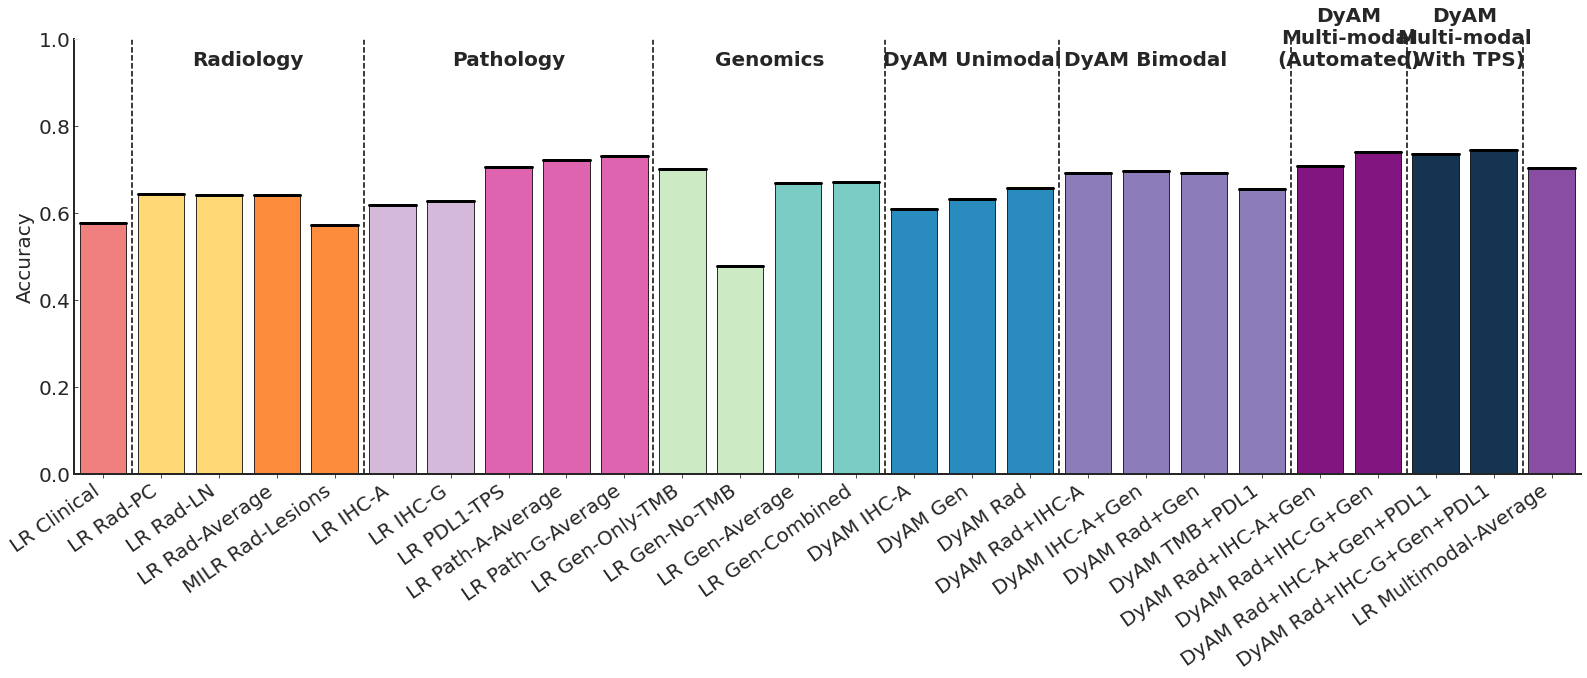

In [43]:
importlib.reload(lung_helpers)
from lung_helpers import *

df_metrics = generate_metric_plot_V2(summary_dfs,  
    models=filter_dict(model_dict, cln_models + rad_train_models + path_train_models + genomic_train_models + DyAM_models), 
    annot_list=annot_list, panel='EF3')

In [44]:
print (df_metrics.to_latex(index=False))

\begin{tabular}{lrrrrr}
\toprule
                  Model &  F1-score &  Precision Score &  Recall Score &      AUC &  Accuracy \\
\midrule
            LR Clinical &  0.680982 &         0.787234 &      0.600000 & 0.569517 &  0.577236 \\
              LR Rad-PC &  0.736364 &         0.810000 &      0.675000 & 0.640698 &  0.644172 \\
              LR Rad-LN &  0.700000 &         0.756757 &      0.651163 & 0.681202 &  0.641791 \\
         LR Rad-Average &  0.728745 &         0.810811 &      0.661765 & 0.655709 &  0.641711 \\
       MILR Rad-Lesions &  0.666667 &         0.769231 &      0.588235 & 0.611664 &  0.572193 \\
               LR IHC-A &  0.666667 &         0.701754 &      0.634921 & 0.624339 &  0.619048 \\
               LR IHC-G &  0.666667 &         0.722222 &      0.619048 & 0.633787 &  0.628571 \\
            LR PDL1-TPS &  0.788530 &         0.839695 &      0.743243 & 0.729284 &  0.706468 \\
      LR Path-A-Average &  0.802817 &         0.838235 &      0.770270 & 0.695117 &  

In [45]:
summary_dfs['DyAM Rad+IHC-A+Gen+PDL1'].loc['P-0021769'] # Our special patient

label                       0.000000
score                      -1.032462
fold                        1.000000
risk_rad_lesion_pc         -0.485338
risk_rad_lesion_pl         -0.501616
risk_rad_lesion_ln         -0.000000
risk_path_ihc_pdl1         -0.000000
risk_gen_driver_mut_amp    -0.999970
risk_cnl_pdl1_score         0.000000
attn_rad_lesion_pc          0.345639
attn_rad_lesion_pl          0.350707
attn_rad_lesion_ln          0.000000
attn_path_ihc_pdl1          0.000000
attn_gen_driver_mut_amp     0.303653
attn_cnl_pdl1_score         0.000000
share_rad_lesion_pc         1.036918
share_rad_lesion_pl         1.052122
share_rad_lesion_ln         0.000000
share_path_ihc_pdl1         0.000000
share_gen_driver_mut_amp    0.910960
share_cnl_pdl1_score        0.000000
score_norm                  0.176384
error                       0.176384
Name: P-0021769, dtype: float64

In [46]:
print (df_clinical['pfs'].sort_values(ascending=True).iloc[compute_jk(247, 0.5, 1.96)])
print (df_tmb['TMB'].sort_values(ascending=True).iloc[compute_jk(247, 0.5, 1.96)])

df_genomic[['TMB','EGFR driver_binarized', 'STK11 driver_binarized']].describe()
df_genomic[['TMB','EGFR driver_binarized', 'STK11 driver_binarized']].sum()

main_index
P-0025598    2.5
P-0008878    2.7
P-0031665    3.0
Name: pfs, dtype: float64
main_index
P-0031112    7
P-0003247    7
P-0024421    7
Name: TMB, dtype: int64


TMB                       2515
EGFR driver_binarized       22
STK11 driver_binarized      44
dtype: int64

AUC 0.440 +/- 0.083 95% CL: [Albumin             ] 
AUC 0.486 +/- 0.084 95% CL: [Age                 ] 
AUC 0.440 +/- 0.079 95% CL: [Pack-Years          ] 
AUC 0.547 +/- 0.071 95% CL: [Diagnostic Site (Lung)] 
AUC 0.421 +/- 0.084 95% CL: [Overall Tumor Burden] 
AUC 0.493 +/- 0.064 95% CL: [GE Revolution       ] 
AUC 0.524 +/- 0.065 95% CL: [Adenocarcinoma      ] 
AUC 0.560 +/- 0.050 95% CL: [Recieves PD-L1 Therapy] 
AUC 0.525 +/- 0.050 95% CL: [GE Lightspeed       ] 
AUC 0.434 +/- 0.087 95% CL: [CT XRay mA range    ] 
AUC 0.501 +/- 0.063 95% CL: [Liver Mets          ] 
AUC 0.544 +/- 0.061 95% CL: [Brain Mets          ] 
AUC 0.594 +/- 0.080 95% CL: [Lines of Therapy    ] 
AUC 0.522 +/- 0.023 95% CL: [Recieves Combination Therapy] 
AUC 0.764 +/- 0.069 95% CL: [DyAM Model Score    ] 
AUC 0.527 +/- 0.083 95% CL: [dNLR                ] 
6A-Covariates


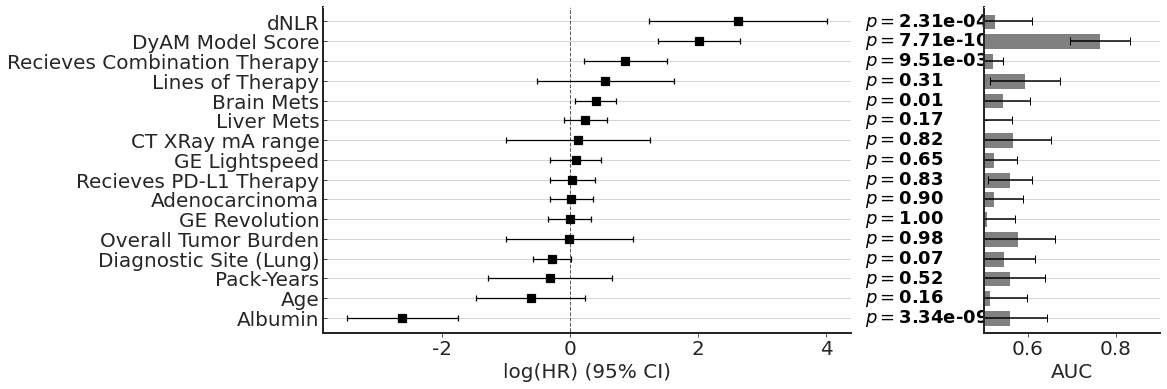

In [47]:
importlib.reload(lung_helpers)
from lung_helpers import *

generate_cox_plot_V2(
    [summary_dfs['DyAM Rad+IHC-A+Gen+PDL1']['score'], df_clinical[['age', 'pack_years', 'albumin','dnlr', 'liver_mets', 'therapy_line', 'brain_mets', 'tumor_burden', 'site_lung', 'recieves_pdl1_therapy', 'XRayTubeCurrent_range', 'recieves_combo_therapy', 'hist_adeno','scanner_lightspeed', 'scanner_revolution']]], 
    df_clinical,
    label_map={
        'age': 'Age',
        'pack_years': 'Pack-Years',
        'albumin': 'Albumin',
        'dnlr': 'dNLR',
        'therapy_line': "Lines of Therapy",
        'liver_mets': 'Liver Mets',
        'brain_mets': 'Brain Mets',
        'tumor_burden': 'Overall Tumor Burden',
        'recieves_pdl1_therapy': 'Recieves PD-L1 Therapy',
        'recieves_combo_therapy': 'Recieves Combination Therapy',
        'XRayTubeCurrent_range': 'CT XRay mA range',
        'scanner_lightspeed': 'GE Lightspeed',
        'scanner_revolution': 'GE Revolution',
        'score': 'DyAM Model Score',
        'hist_adeno': "Adenocarcinoma",
        'site_lung': "Diagnostic Site (Lung)",
        'site_ln': "Diagnostic Site (Node)",
        'site_bone': "Diagnostic Site (Bone)"
    },
    xlim=(-3.5, 3.5), panel='6A-Covariates')
plt.savefig('vector_figs/5A-main.svg', bbox_inches='tight')


AUC 0.461 +/- 0.046 95% CL: [Pleural Lesion Risk ] 
AUC 0.586 +/- 0.090 95% CL: [IHC-A Risk          ] 
AUC 0.575 +/- 0.072 95% CL: [Nodal Lesion Risk   ] 
AUC 0.612 +/- 0.080 95% CL: [Parenchymal Lesion Risk] 
AUC 0.703 +/- 0.077 95% CL: [PDL1-TPS Risk       ] 
AUC 0.655 +/- 0.078 95% CL: [Genomic Risk        ] 
AUC 0.764 +/- 0.069 95% CL: [Overall Score       ] 
6A-Dyam


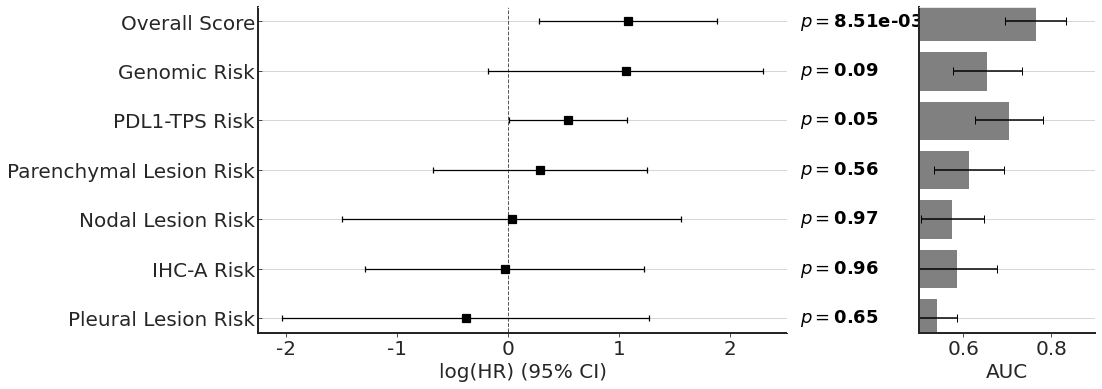

In [48]:
importlib.reload(lung_helpers)
from lung_helpers import *
generate_cox_plot_V2(
    [summary_dfs['DyAM Rad+IHC-A+Gen+PDL1']['score'], summary_dfs['LR Multimodal-Average'].loc[:, summary_dfs['LR Multimodal-Average'].columns.str.contains('risk')],
    
    ], 
    df_clinical,
    label_map={
        'risk_lr rad-pc': 'Parenchymal Lesion Risk',
        'risk_lr rad-pl': 'Pleural Lesion Risk',
        'risk_lr rad-ln': 'Nodal Lesion Risk',
        'risk_lr ihc-a': 'IHC-A Risk',
        'risk_gen_driver_non_tmb': 'Driver Mutations',
        'risk_gen_driver_tmb':'TMB Risk',
        'risk_lr gen-combined': 'Genomic Risk',
        'risk_lr pdl1-tps': 'PDL1-TPS Risk',
        
        'risk_rad_lesion_pc': 'Parenchymal Lesion Risk',
        'risk_rad_lesion_pl': 'Pleural Lesion Risk',
        'risk_rad_lesion_ln': 'Nodal Lesion Risk',
        'risk_path_ihc_pdl1': 'IHC-A Risk',
        'risk_gen_driver_non_tmb': 'Driver Mutations',
        'risk_gen_driver_tmb':'TMB Risk',
        'risk_gen_driver_mut_amp': 'Genomic Risk',
        'risk_cnl_pdl1_score': 'PDL1-TPS Risk',
        'score': 'Overall Score'
    },
    xlim=(-3.5, 3.5), panel='6A-Dyam')
plt.savefig('vector_figs/5A-partials.svg', bbox_inches='tight')

In [49]:
importlib.reload(lung_helpers)
from lung_helpers import *

label_mapping = {
    'risk_rad_lesion_pc':{'label':"Partial Risk-PC", 'color':rad_colors[0]},
    'risk_path_ihc_pdl1':{'label':"Partial Risk-IHC-A", 'color':rad_colors[0]},
    'risk_gen_driver_non_tmb':{'label':"Partial Risk-Genomics", 'color':rad_colors[0]},
    'risk_cnl_pdl1_score':{'label':"Partial Risk-TPS", 'color':rad_colors[0]},
    'overall_score': {'label':'Overall DyAM Score','color':rad_colors[0]},
  
    
    'attn_rad_lesion_pc':{'label':"Parenchymal Attention", 'color':rad_colors[1]},
    'attn_rad_lesion_pl':{'label':"Pleural Attention", 'color':rad_colors[2]},
    'attn_rad_lesion_ln':{'label':"Nodal Attention", 'color':'#71090D'},
    'attn_path_ihc_pdl1':{'label':"IHC-A Attention", 'color':None},
    'attn_path_ihc_glcm':{'label':"IHC-A Attention", 'color':None},
    'attn_gen_driver_non_tmb':{'label':"Genomic Attention", 'color':genomic_colors[1]},
    'attn_gen_driver_tmb':{'label': "TMB Attention",'color':genomic_colors[2]},
    'attn_gen_driver_mut_amp':{'label':"Genomic Attention",'color':genomic_colors[1]},
    'attn_cnl_pdl1_score':{'label': "TPS Attention",'color':path_colors[1]},
}


['attn_rad_lesion_pc', 'attn_rad_lesion_pl', 'attn_rad_lesion_ln', 'attn_path_ihc_pdl1', 'attn_gen_driver_mut_amp', 'attn_cnl_pdl1_score']
['attn_rad_lesion_pc', 'attn_rad_lesion_pl', 'attn_rad_lesion_ln', 'attn_path_ihc_pdl1', 'attn_gen_driver_mut_amp', 'attn_cnl_pdl1_score']
['attn_rad_lesion_pc', 'attn_rad_lesion_pl', 'attn_rad_lesion_ln', 'attn_path_ihc_pdl1', 'attn_gen_driver_mut_amp', 'attn_cnl_pdl1_score']


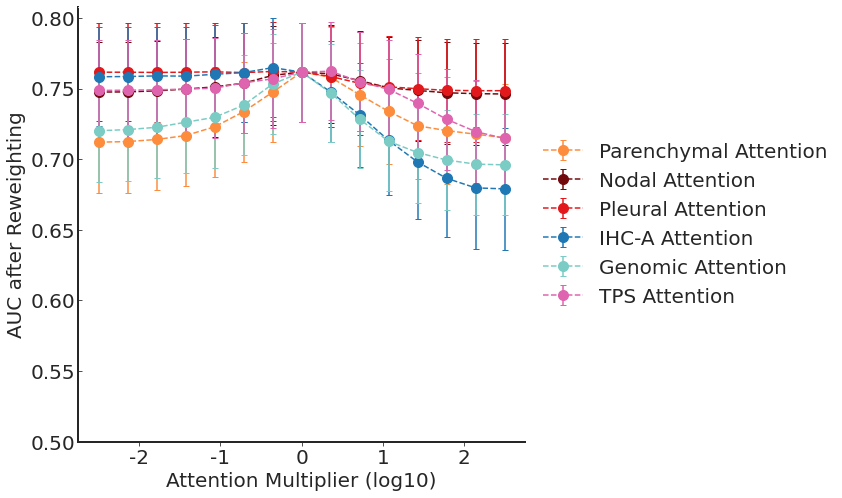

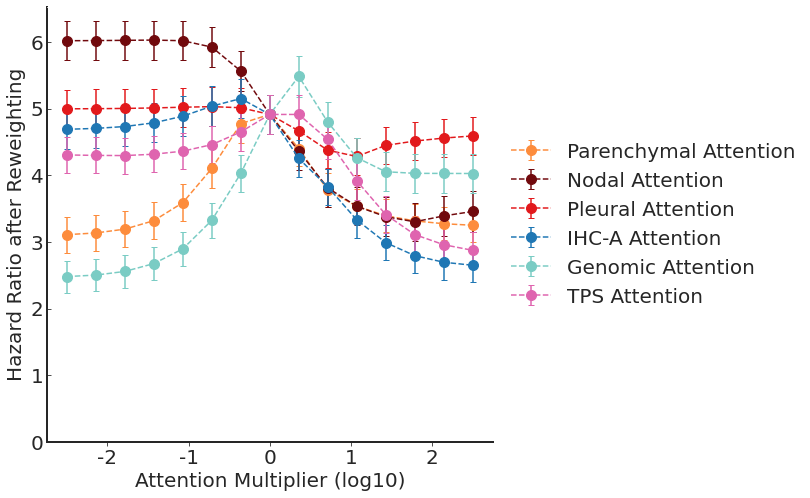

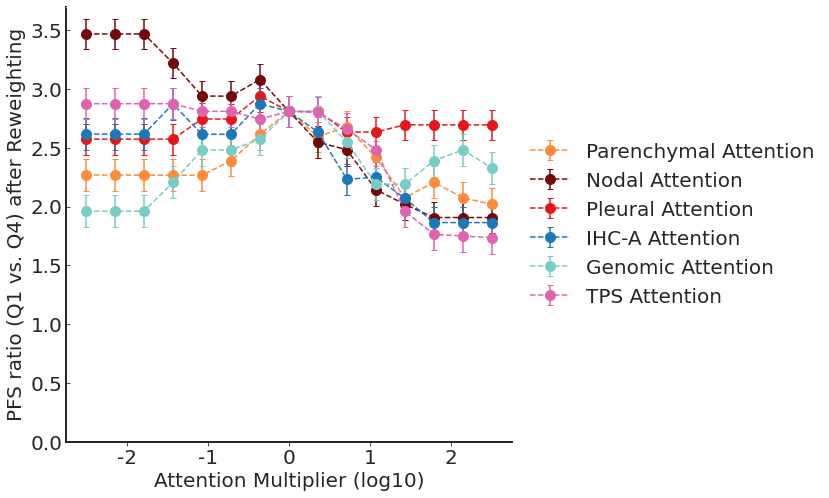

In [50]:
importlib.reload(lung_helpers)
from lung_helpers import *

generate_alpine_plot_V2(summary_dfs['DyAM Rad+IHC-A+Gen+PDL1'], df_clinical, x_axes=['attn_rad_lesion_pc','attn_rad_lesion_ln', 'attn_rad_lesion_pl',  'attn_path_ihc_pdl1','attn_gen_driver_mut_amp', 'attn_cnl_pdl1_score'], stat='auc', label_mapping=label_mapping, panel='6C-AUC')
plt.savefig('vector_figs/6C-alp_best_auc.svg', bbox_inches='tight')
generate_alpine_plot_V2(summary_dfs['DyAM Rad+IHC-A+Gen+PDL1'], df_clinical, x_axes=['attn_rad_lesion_pc', 'attn_rad_lesion_ln', 'attn_rad_lesion_pl','attn_path_ihc_pdl1','attn_gen_driver_mut_amp','attn_cnl_pdl1_score'], stat='hr', label_mapping=label_mapping, panel='6C-HR')
plt.savefig('vector_figs/6C-alp_best_hr.svg', bbox_inches='tight')
generate_alpine_plot_V2(summary_dfs['DyAM Rad+IHC-A+Gen+PDL1'], df_clinical, x_axes=['attn_rad_lesion_pc', 'attn_rad_lesion_ln', 'attn_rad_lesion_pl', 'attn_path_ihc_pdl1', 'attn_gen_driver_mut_amp', 'attn_cnl_pdl1_score'], stat='kmf', label_mapping=label_mapping, panel='6C-PFSR')
plt.savefig('vector_figs/6C-alp_best_pfsr.svg', bbox_inches='tight')

['attn_lr rad-pc', 'attn_lr rad-pl', 'attn_lr rad-ln', 'attn_lr ihc-a', 'attn_lr pdl1-tps', 'attn_lr gen-combined']
['attn_lr rad-pc', 'attn_lr rad-pl', 'attn_lr rad-ln', 'attn_lr ihc-a', 'attn_lr pdl1-tps', 'attn_lr gen-combined']
['attn_lr rad-pc', 'attn_lr rad-pl', 'attn_lr rad-ln', 'attn_lr ihc-a', 'attn_lr pdl1-tps', 'attn_lr gen-combined']


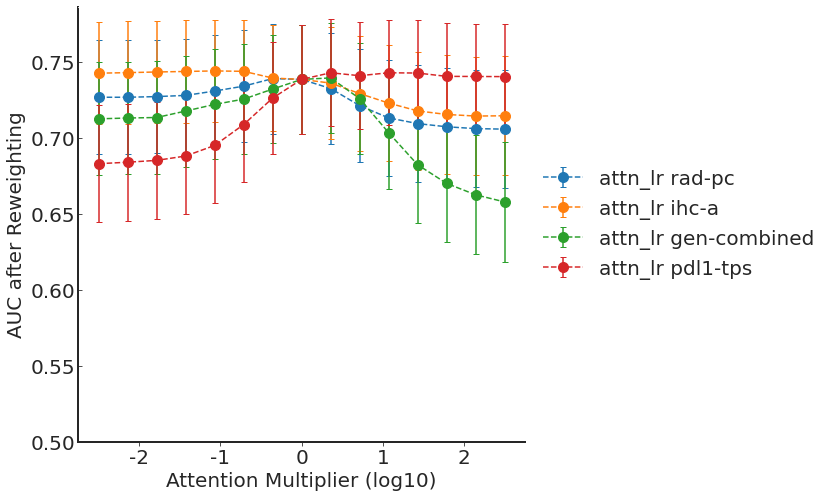

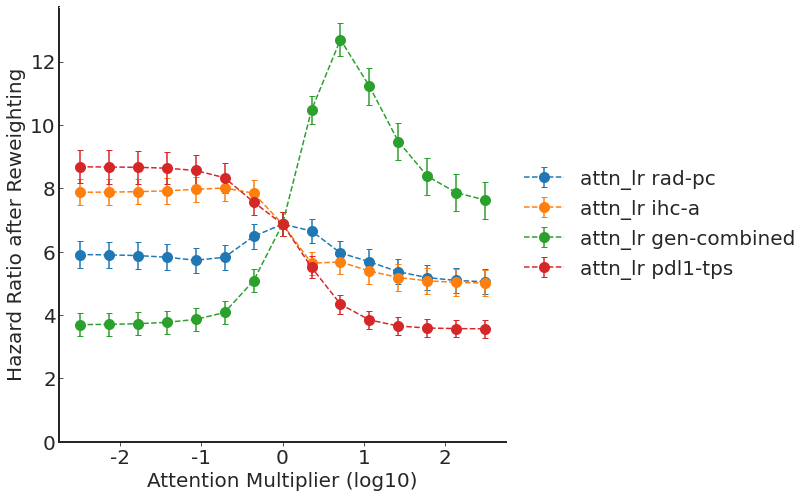

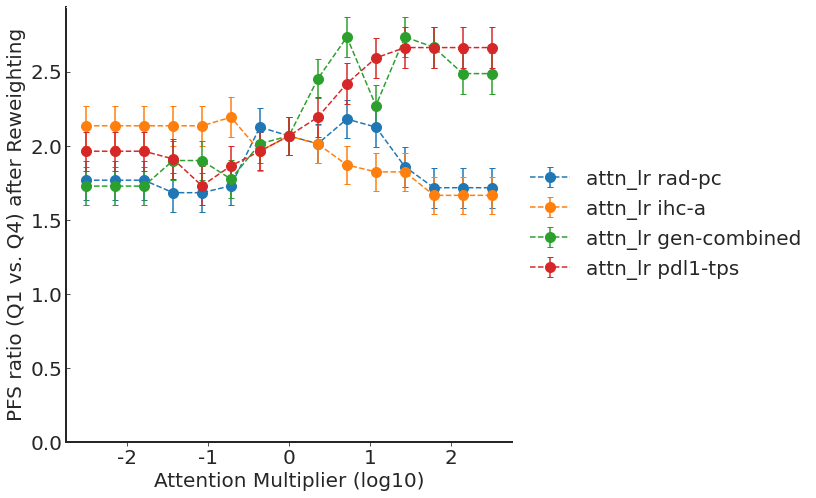

In [51]:
summary_dfs['LR Multimodal-Average'] = average_models(summary_dfs,
 ['LR Rad-PC', 'LR Rad-PL', 'LR Rad-LN', 'LR IHC-A', 'LR PDL1-TPS', 'LR Gen-Combined']
)
summary_dfs['LR Multimodal-Average'] 

generate_alpine_plot_V2(summary_dfs['LR Multimodal-Average'], df_clinical, x_axes=['attn_lr rad-pc', 'attn_lr ihc-a','attn_lr gen-combined', 'attn_lr pdl1-tps'], stat='auc', label_mapping=label_mapping)
plt.savefig('vector_figs/NI-6-alp_LR-average_auc.svg', bbox_inches='tight')
generate_alpine_plot_V2(summary_dfs['LR Multimodal-Average'], df_clinical, x_axes=['attn_lr rad-pc', 'attn_lr ihc-a','attn_lr gen-combined', 'attn_lr pdl1-tps'], stat='hr', label_mapping=label_mapping)
plt.savefig('vector_figs/NI-6-alp_LR-average_auc.svg', bbox_inches='tight')
generate_alpine_plot_V2(summary_dfs['LR Multimodal-Average'], df_clinical, x_axes=['attn_lr rad-pc', 'attn_lr ihc-a','attn_lr gen-combined', 'attn_lr pdl1-tps'], stat='kmf', label_mapping=label_mapping)
plt.savefig('vector_figs/NI-6-alp_LR-average_auc.svg', bbox_inches='tight')

In [52]:
example_dict ={
    "P-0017106": "190365",
    "P-0022001": "190916",
    "P-0032182": "348067",
    "P-0032182": ["HobS18-433128250177", "lowest", "0.539445"], 
    "P-0003247": ["HobS15-209701813672", "median", "3.569494"],
    "P-0004271": ["HobS17-133316532778", "high", "6.736147"],
}

Running binary KM fit on TMB
Threshold= -10.182186234817813
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          21.78 <0.005     18.32


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica


Running quartile KM fit on TMB
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           2.42 0.12      3.06
Running binary KM fit on Sauter PD-L1 Score
Threshold= -10
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          17.15 <0.005     14.82
Running quartile KM fit on Sauter PD-L1 Score
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           1.38 0.24      2.06
Running binary KM fit on score
Threshold= 0
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_nam

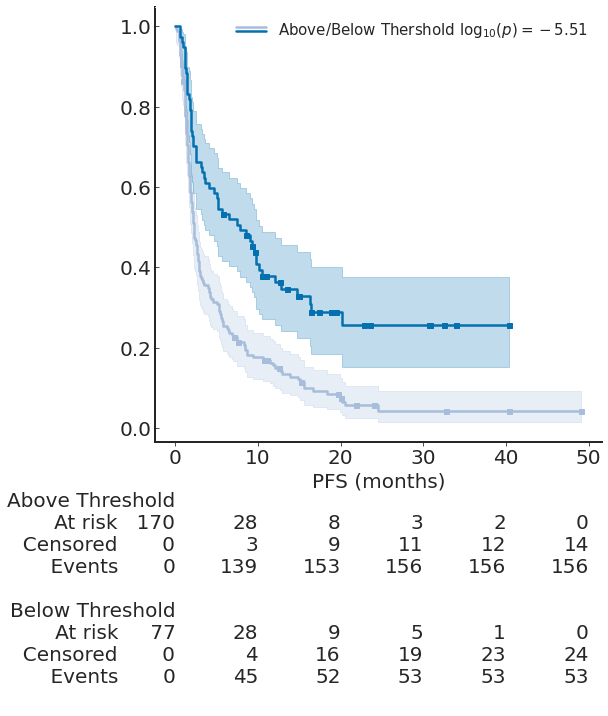

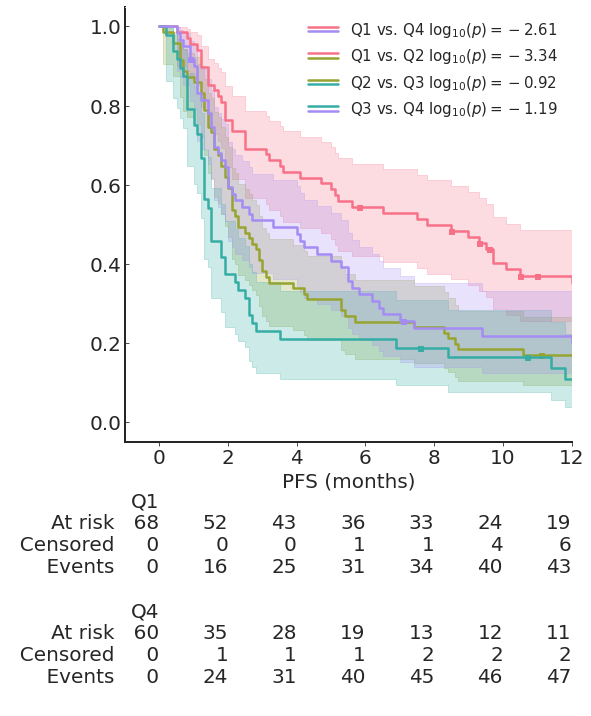

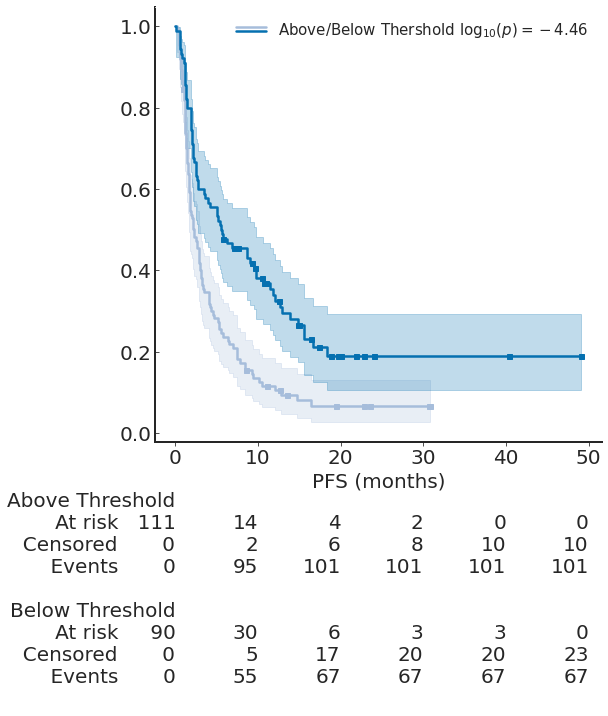

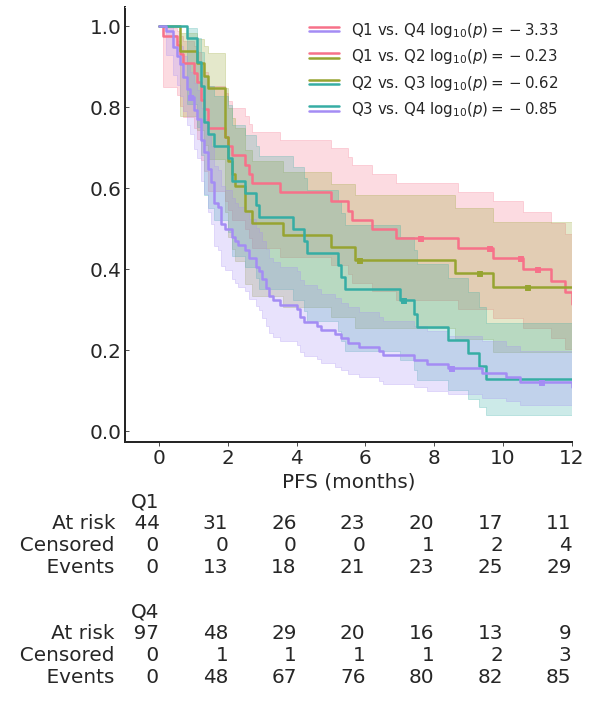

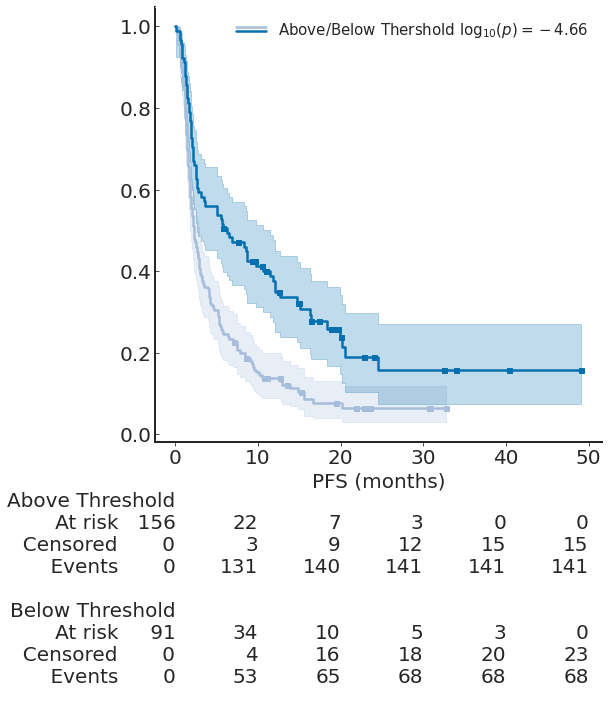

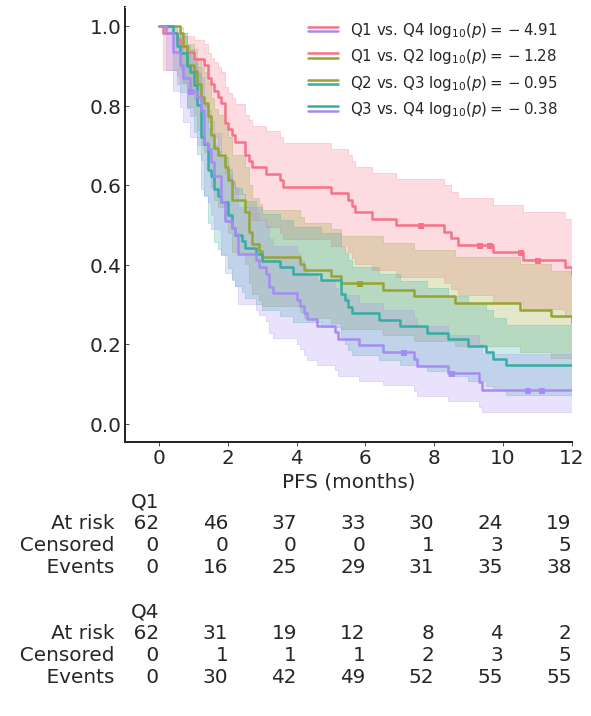

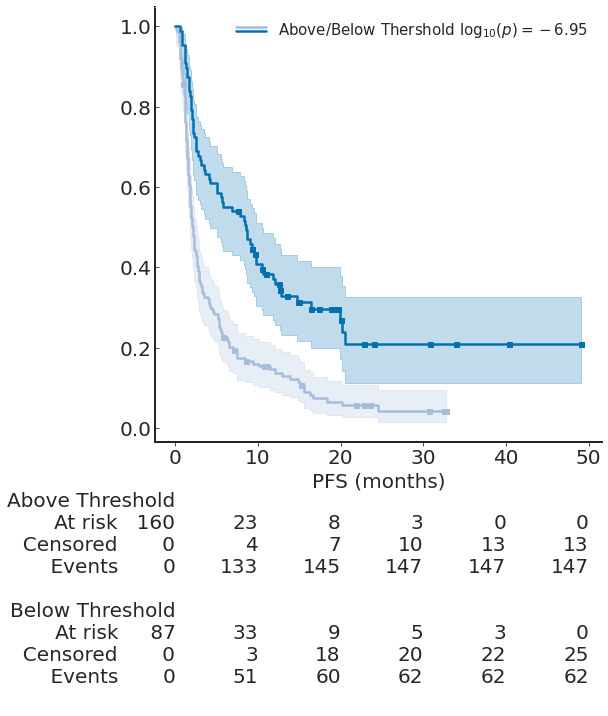

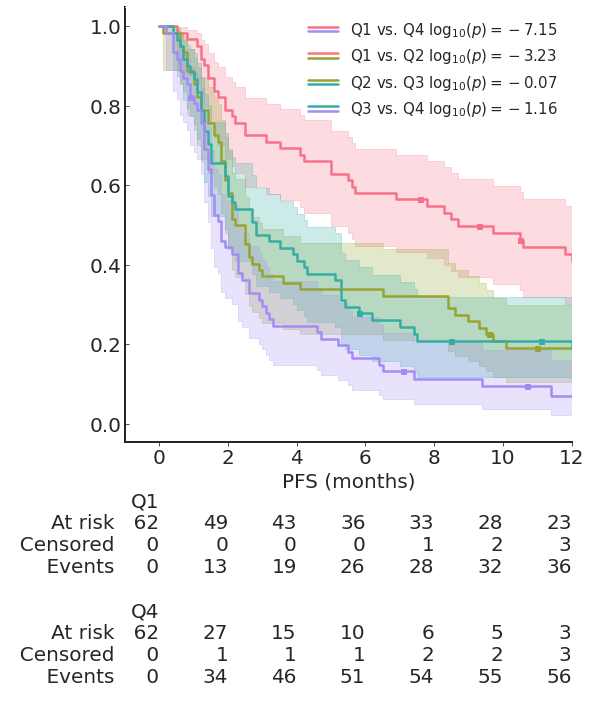

In [53]:
importlib.reload(lung_helpers)
from lung_helpers import *

generate_lifelines_binary(-df_tmb, df_clinical, col='TMB', threshold='mean', panel='5B-TMB')
plt.savefig('vector_figs/5B-KM_tmb.svg', bbox_inches='tight')

generate_lifelines_qcut(-df_tmb, df_clinical, col='TMB', panel='6B-TMB')
plt.savefig('vector_figs/6B-qcut_tmb.svg', bbox_inches='tight')

generate_lifelines_binary(-df_pdl1.astype(int), df_clinical, col='Sauter PD-L1 Score', threshold='auc', panel='5B-TPS')
plt.savefig('vector_figs/5B-KM_tps.svg', bbox_inches='tight')

generate_lifelines_qcut(df_pdl1.astype(int), df_clinical, col='Sauter PD-L1 Score', custom_bins=[0,1,25,75,100], swap=True, panel='6B-TPS')
plt.savefig('vector_figs/6B-tqcut_tps.svg', bbox_inches='tight')

generate_lifelines_binary(summary_dfs['LR Multimodal-Average'], df_clinical, col='score', threshold=0, panel='5B-LR')
plt.savefig('vector_figs/5B-KM_LRavg.svg', bbox_inches='tight')

generate_lifelines_qcut(summary_dfs['LR Multimodal-Average'], df_clinical, panel='6B-LR')
plt.savefig('vector_figs/6B-qcut_LRavg.svg', bbox_inches='tight')

generate_lifelines_binary(summary_dfs['DyAM Rad+IHC-A+Gen+PDL1'], df_clinical, col='score', threshold=0, panel='5B-DyAM')
plt.savefig('vector_figs/5B-KM_DyAM.svg', bbox_inches='tight')

generate_lifelines_qcut(summary_dfs['DyAM Rad+IHC-A+Gen+PDL1'], df_clinical, panel='6B-DyAM')
plt.savefig('vector_figs/6B-qcut_DyAM.svg', bbox_inches='tight')

7
25
8
10
15
100
100


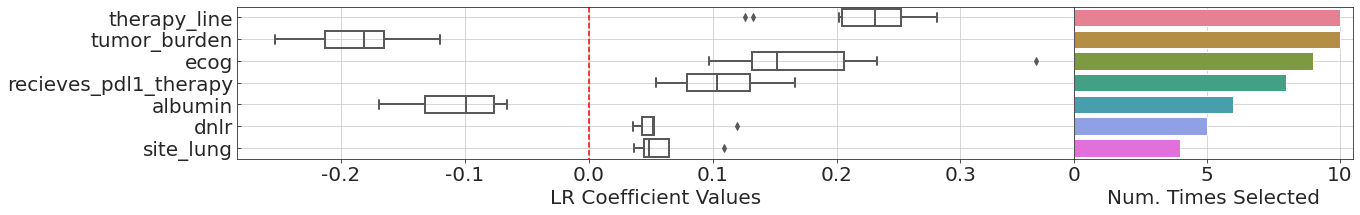

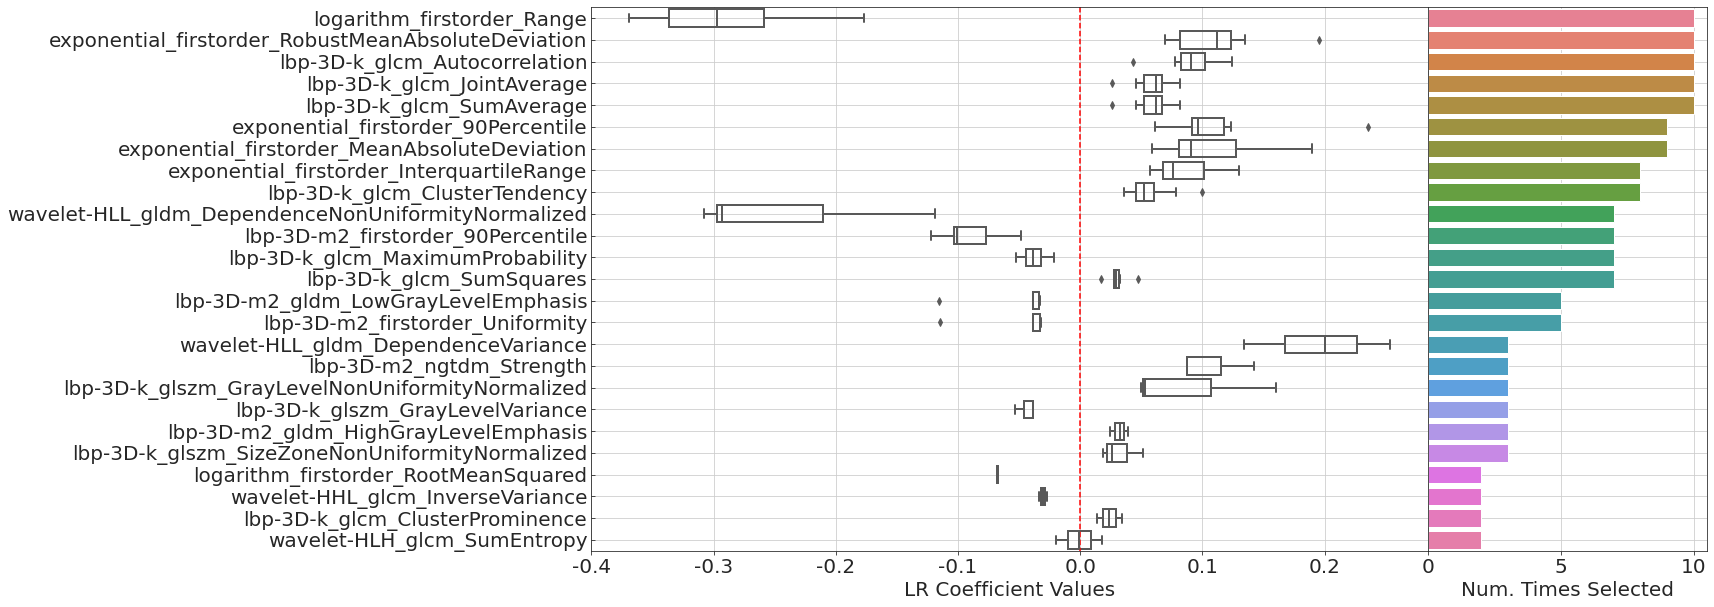

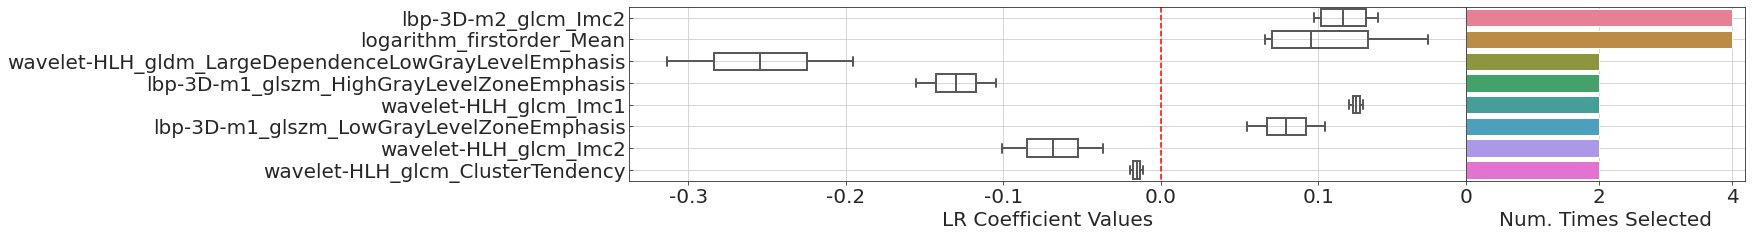

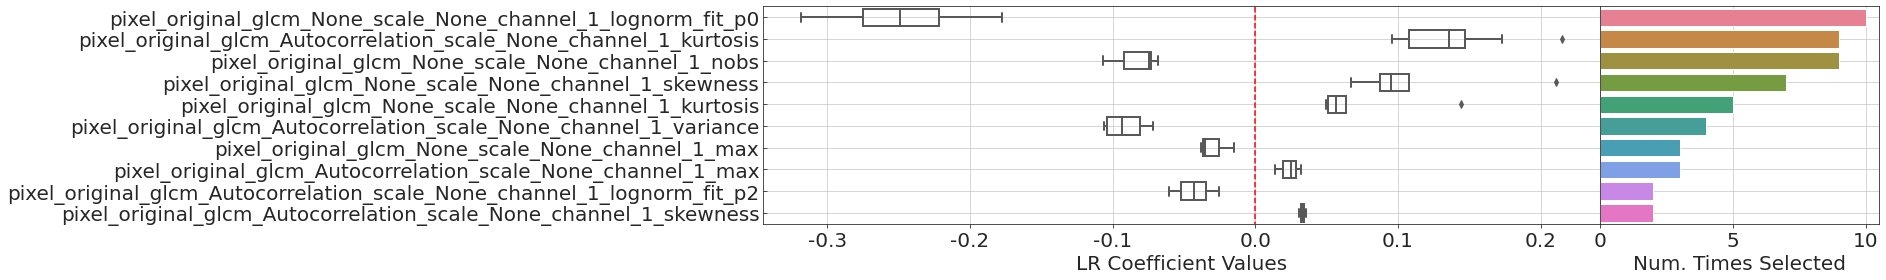

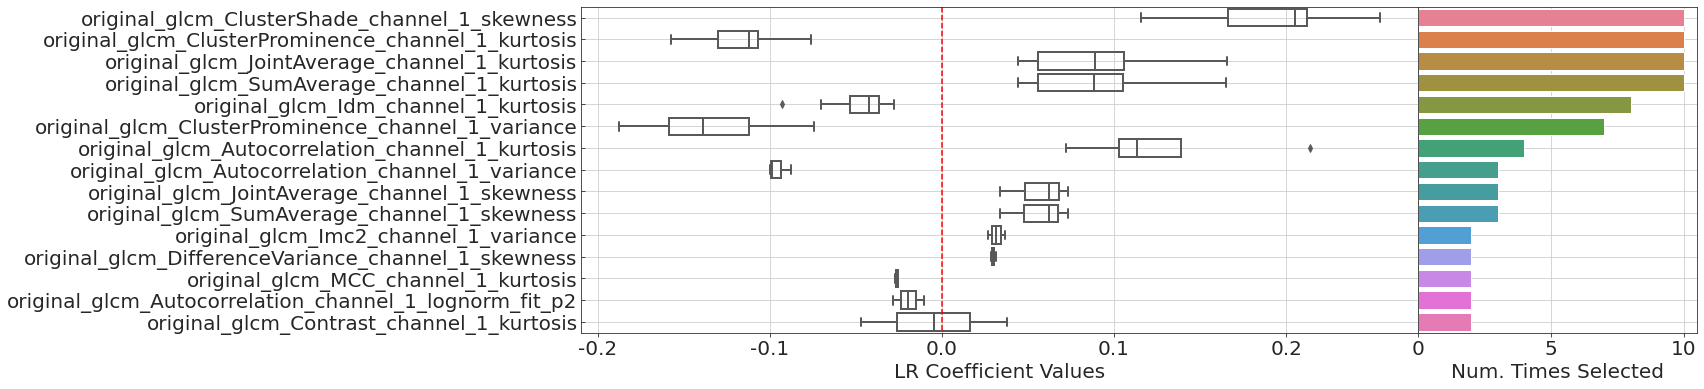

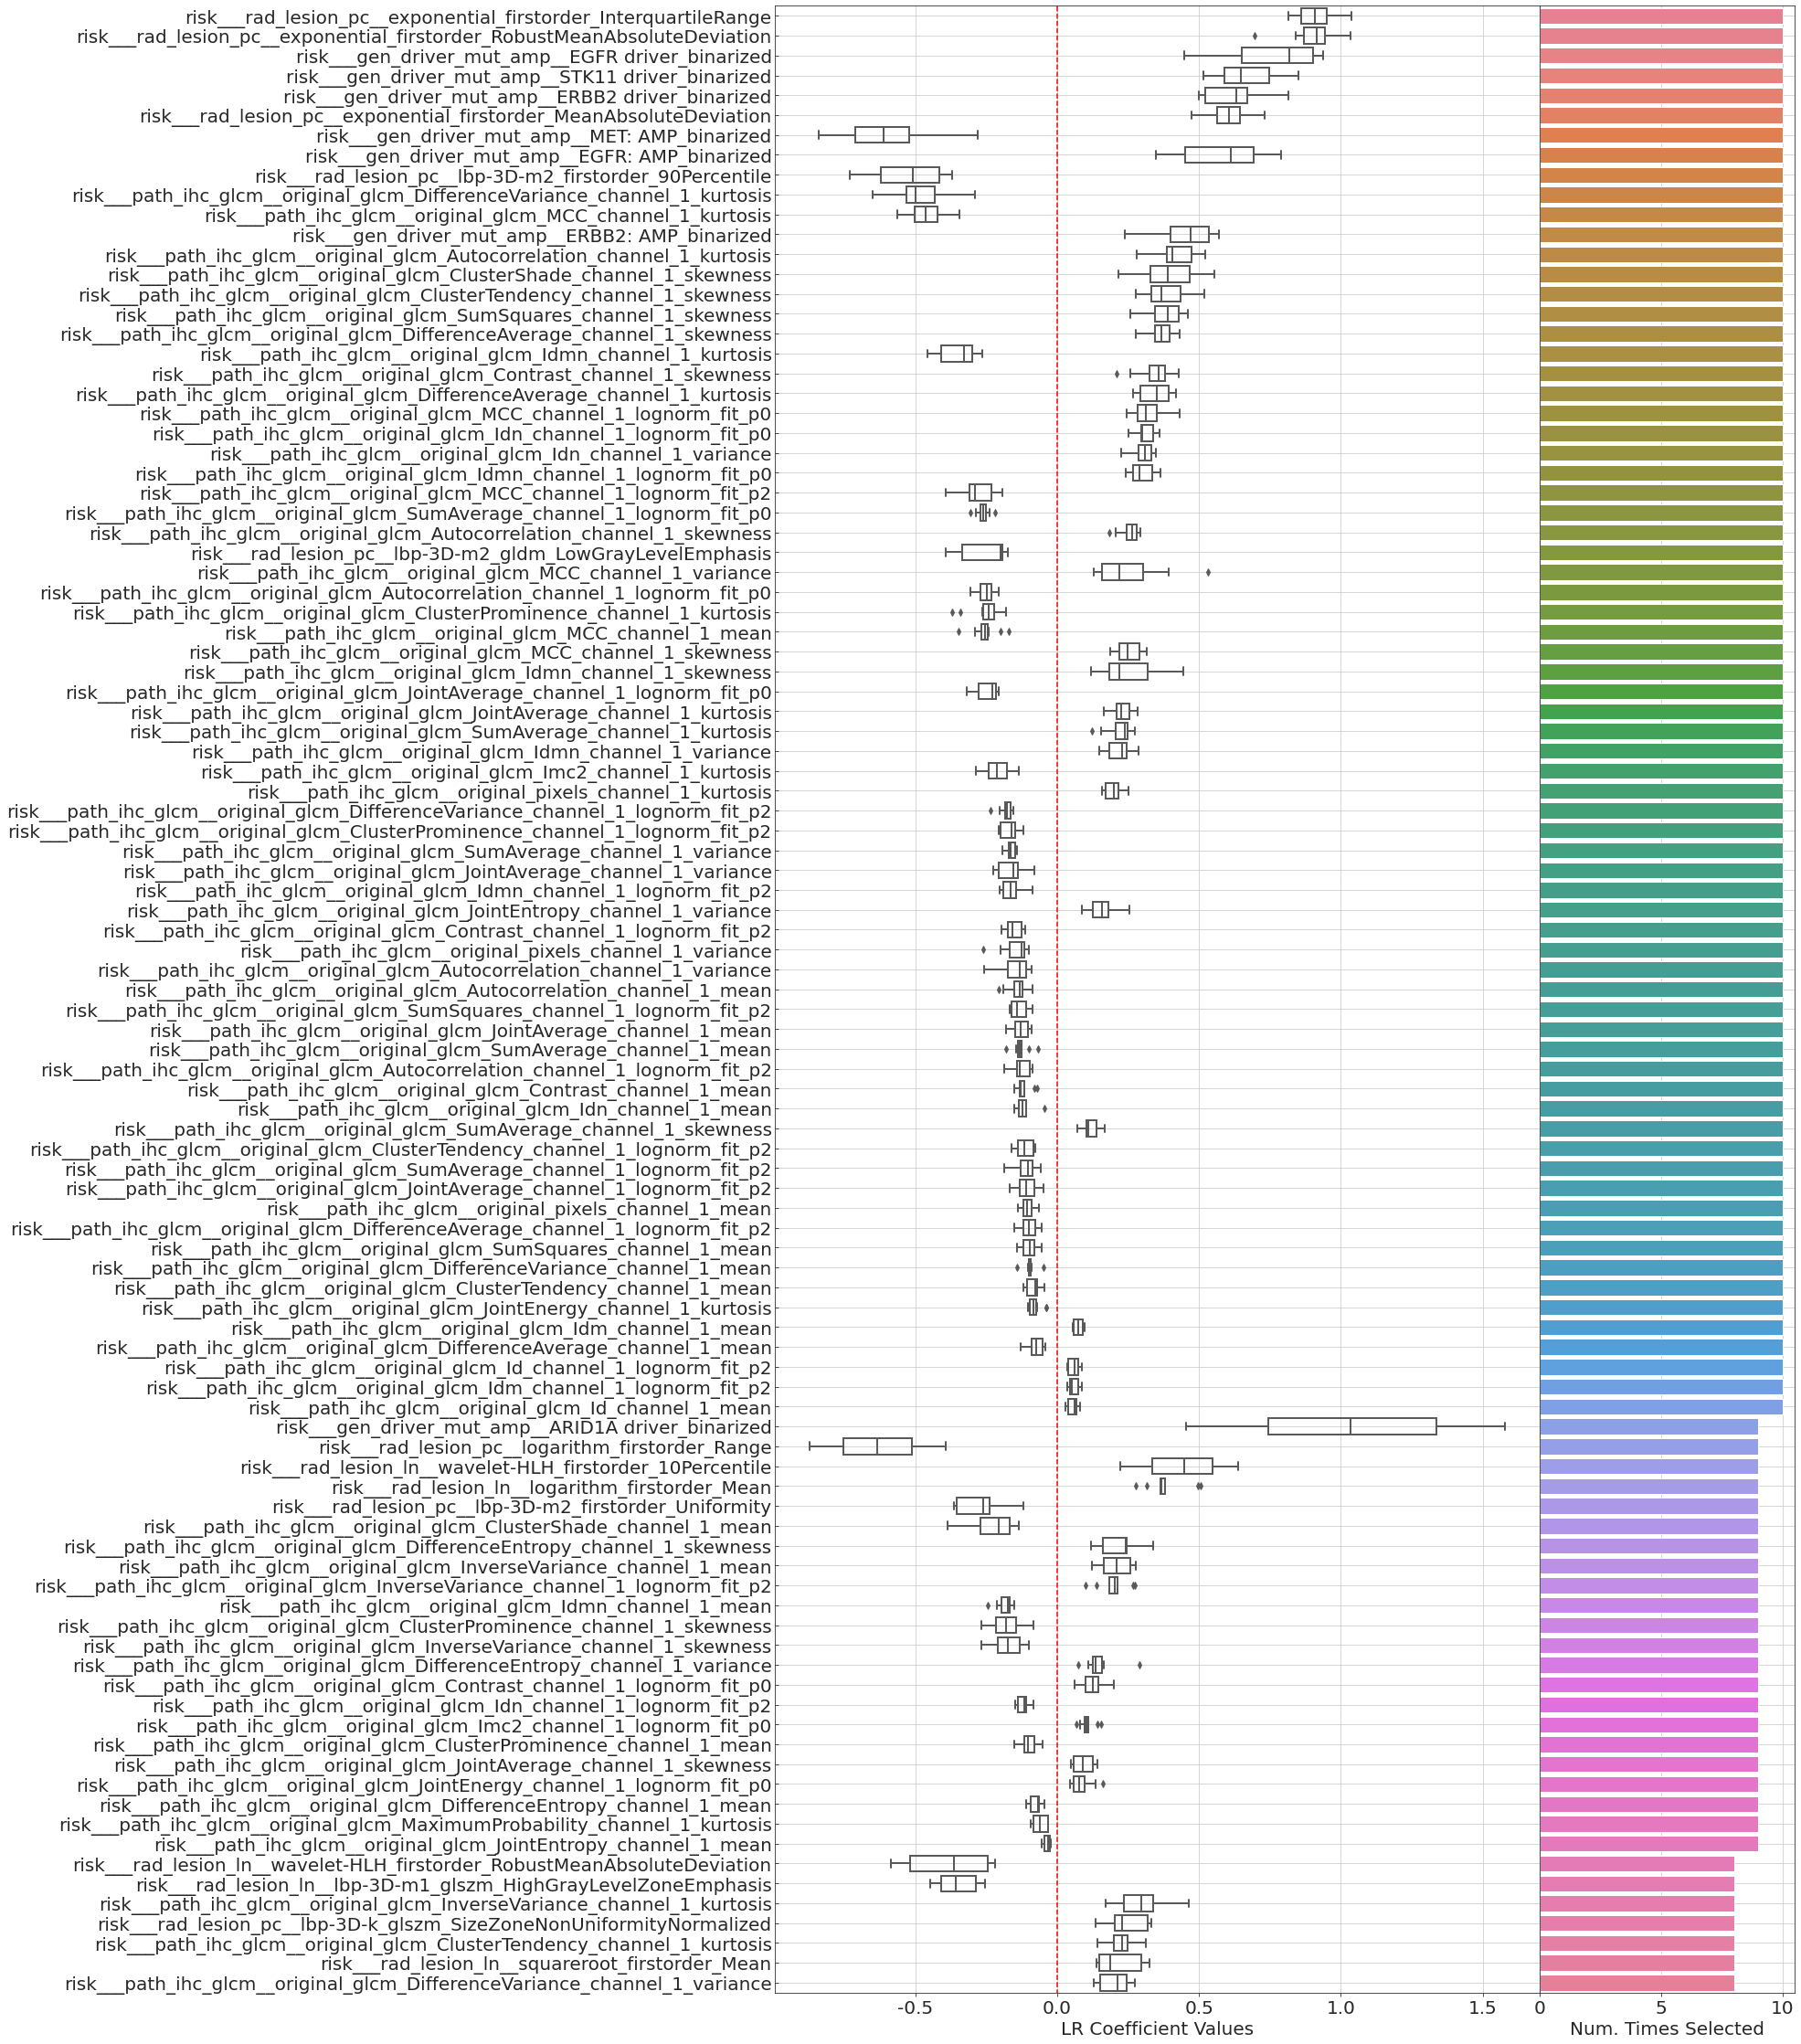

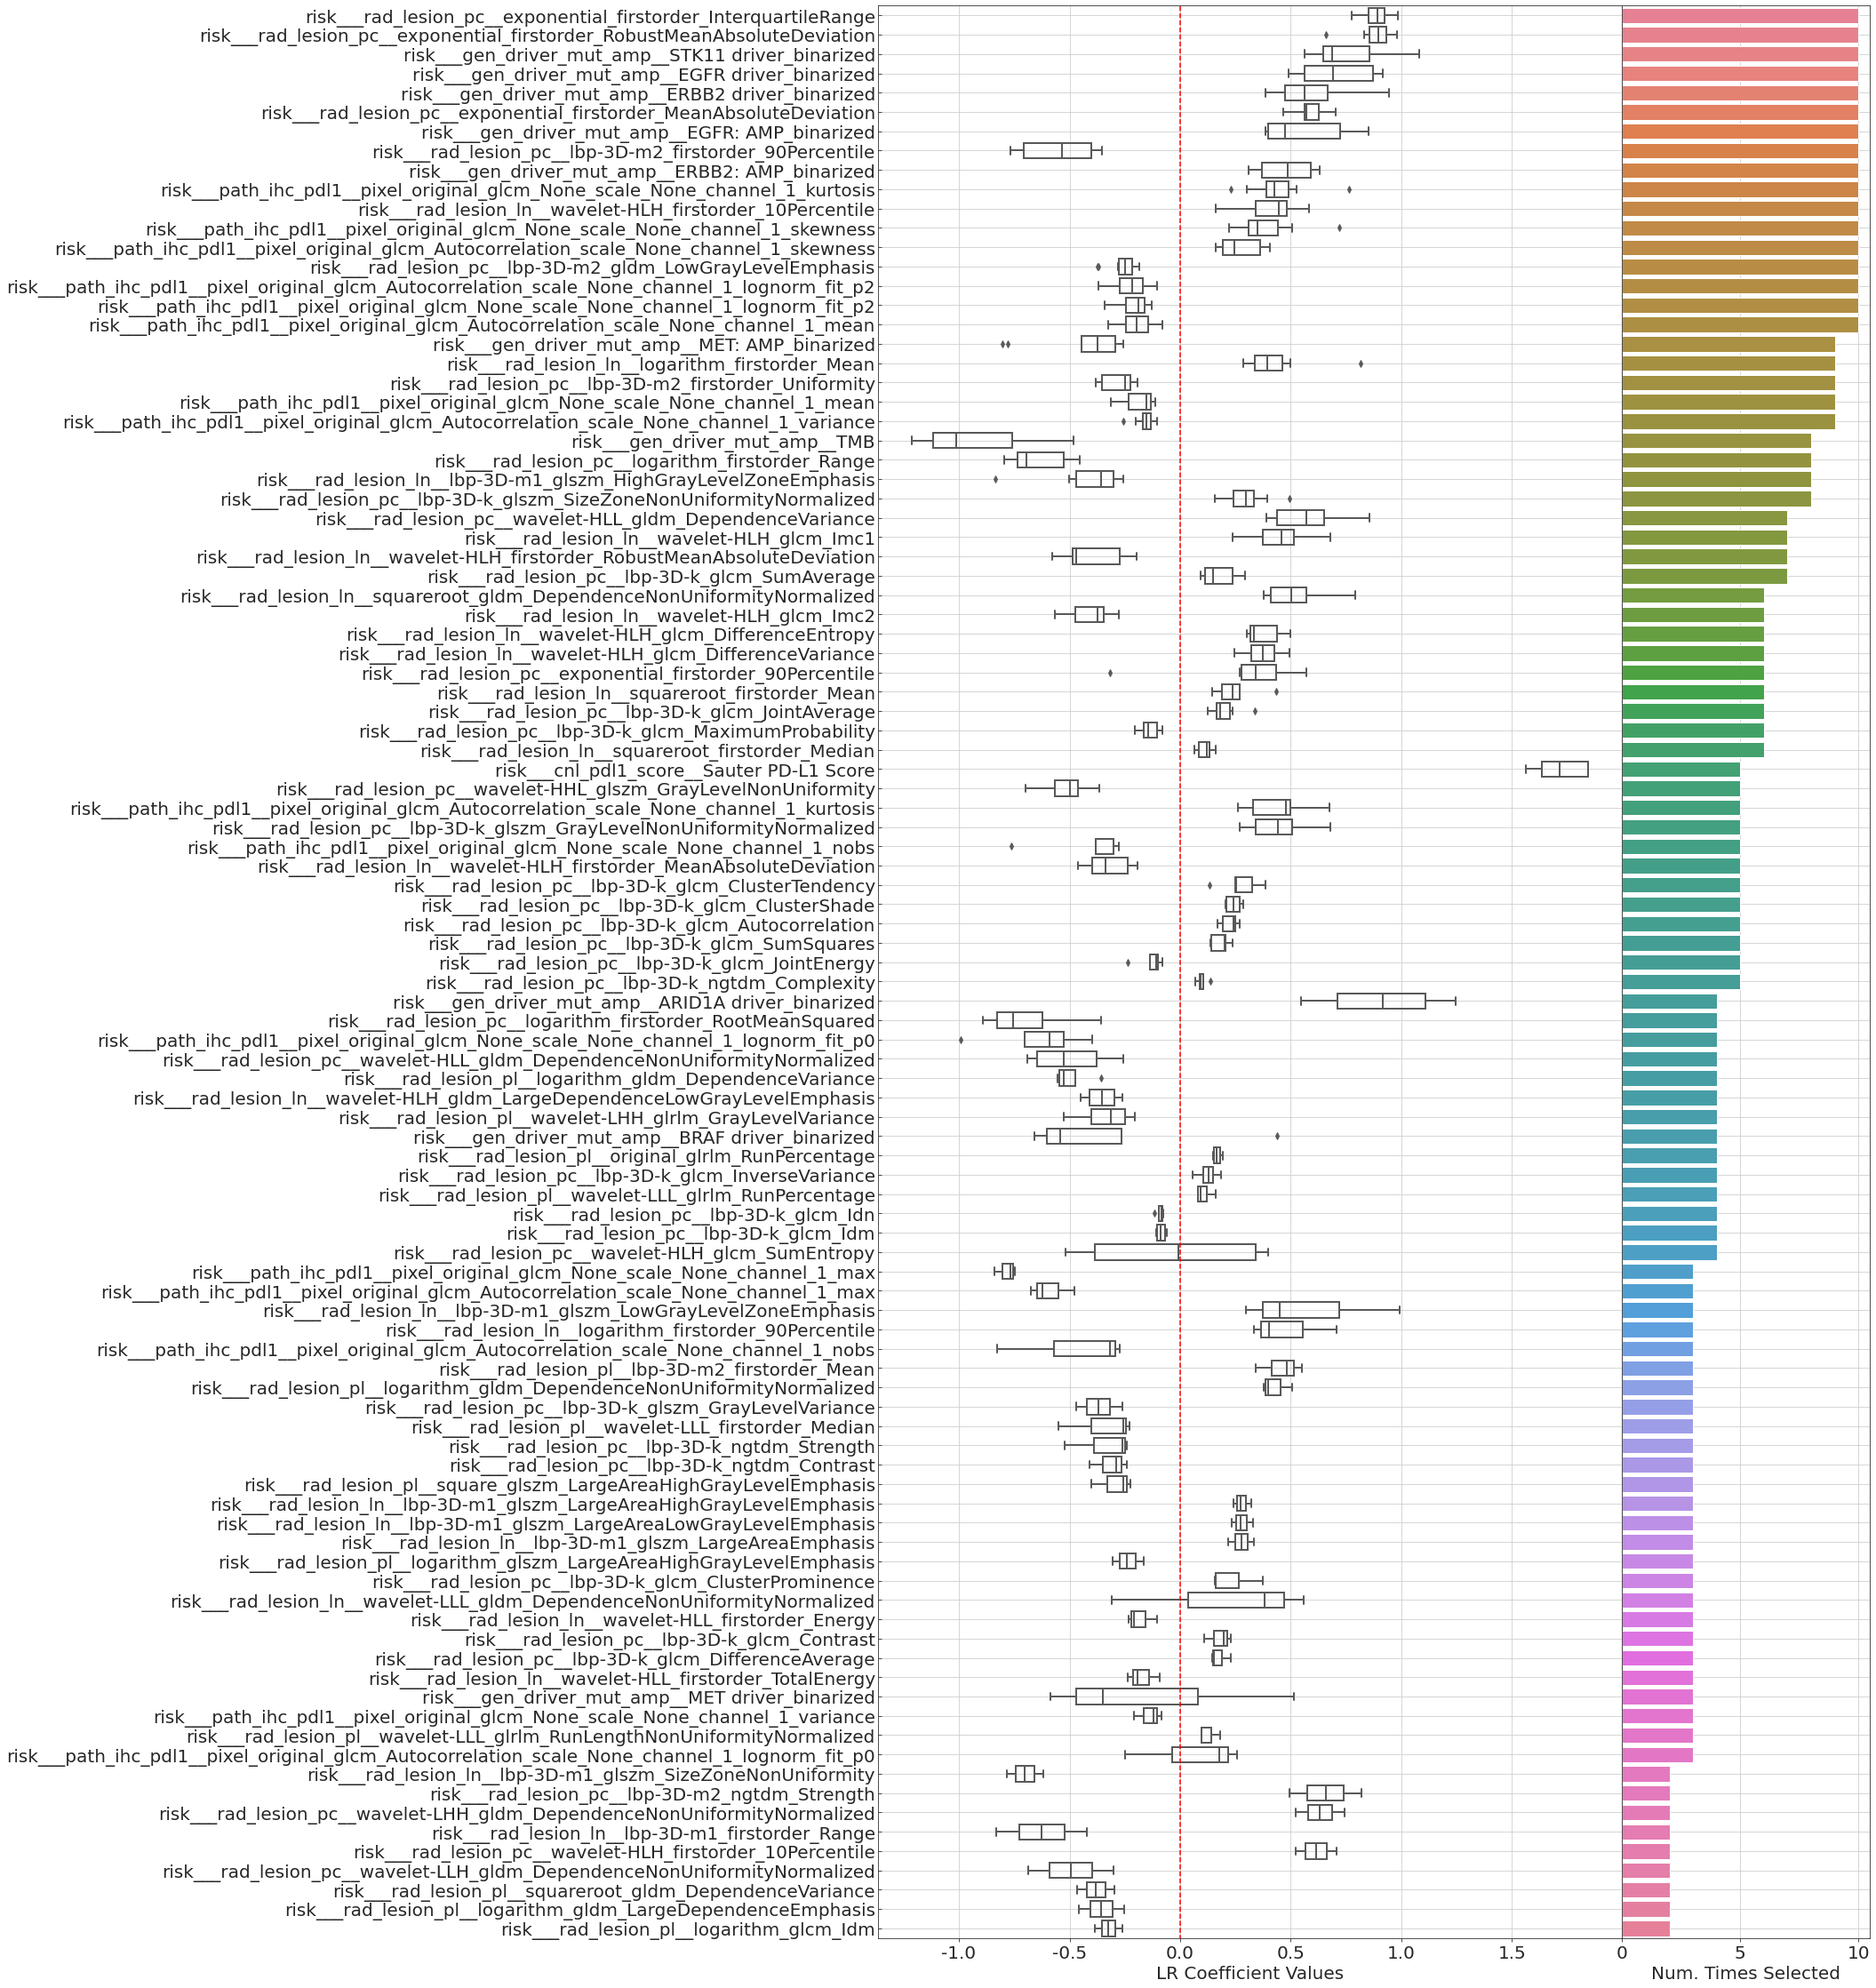

In [54]:
importlib.reload(lung_helpers)
from lung_helpers import *

coefs_to_plot = ['LR Clinical', 'LR Rad-PC', 'LR Rad-LN', 'LR IHC-A', 'LR IHC-G', 'DyAM Rad+IHC-G+Gen', 'DyAM Rad+IHC-A+Gen+PDL1']

for efnumber, ceof_plot in enumerate(coefs_to_plot):
    
    efnumber += 2
    
    plot_coefs ( summary_coefs[ceof_plot] , panel=f'EF{efnumber}')
    plt.savefig(f'vector_figs/EF{efnumber}.svg', bbox_inches='tight')

<AxesSubplot:>

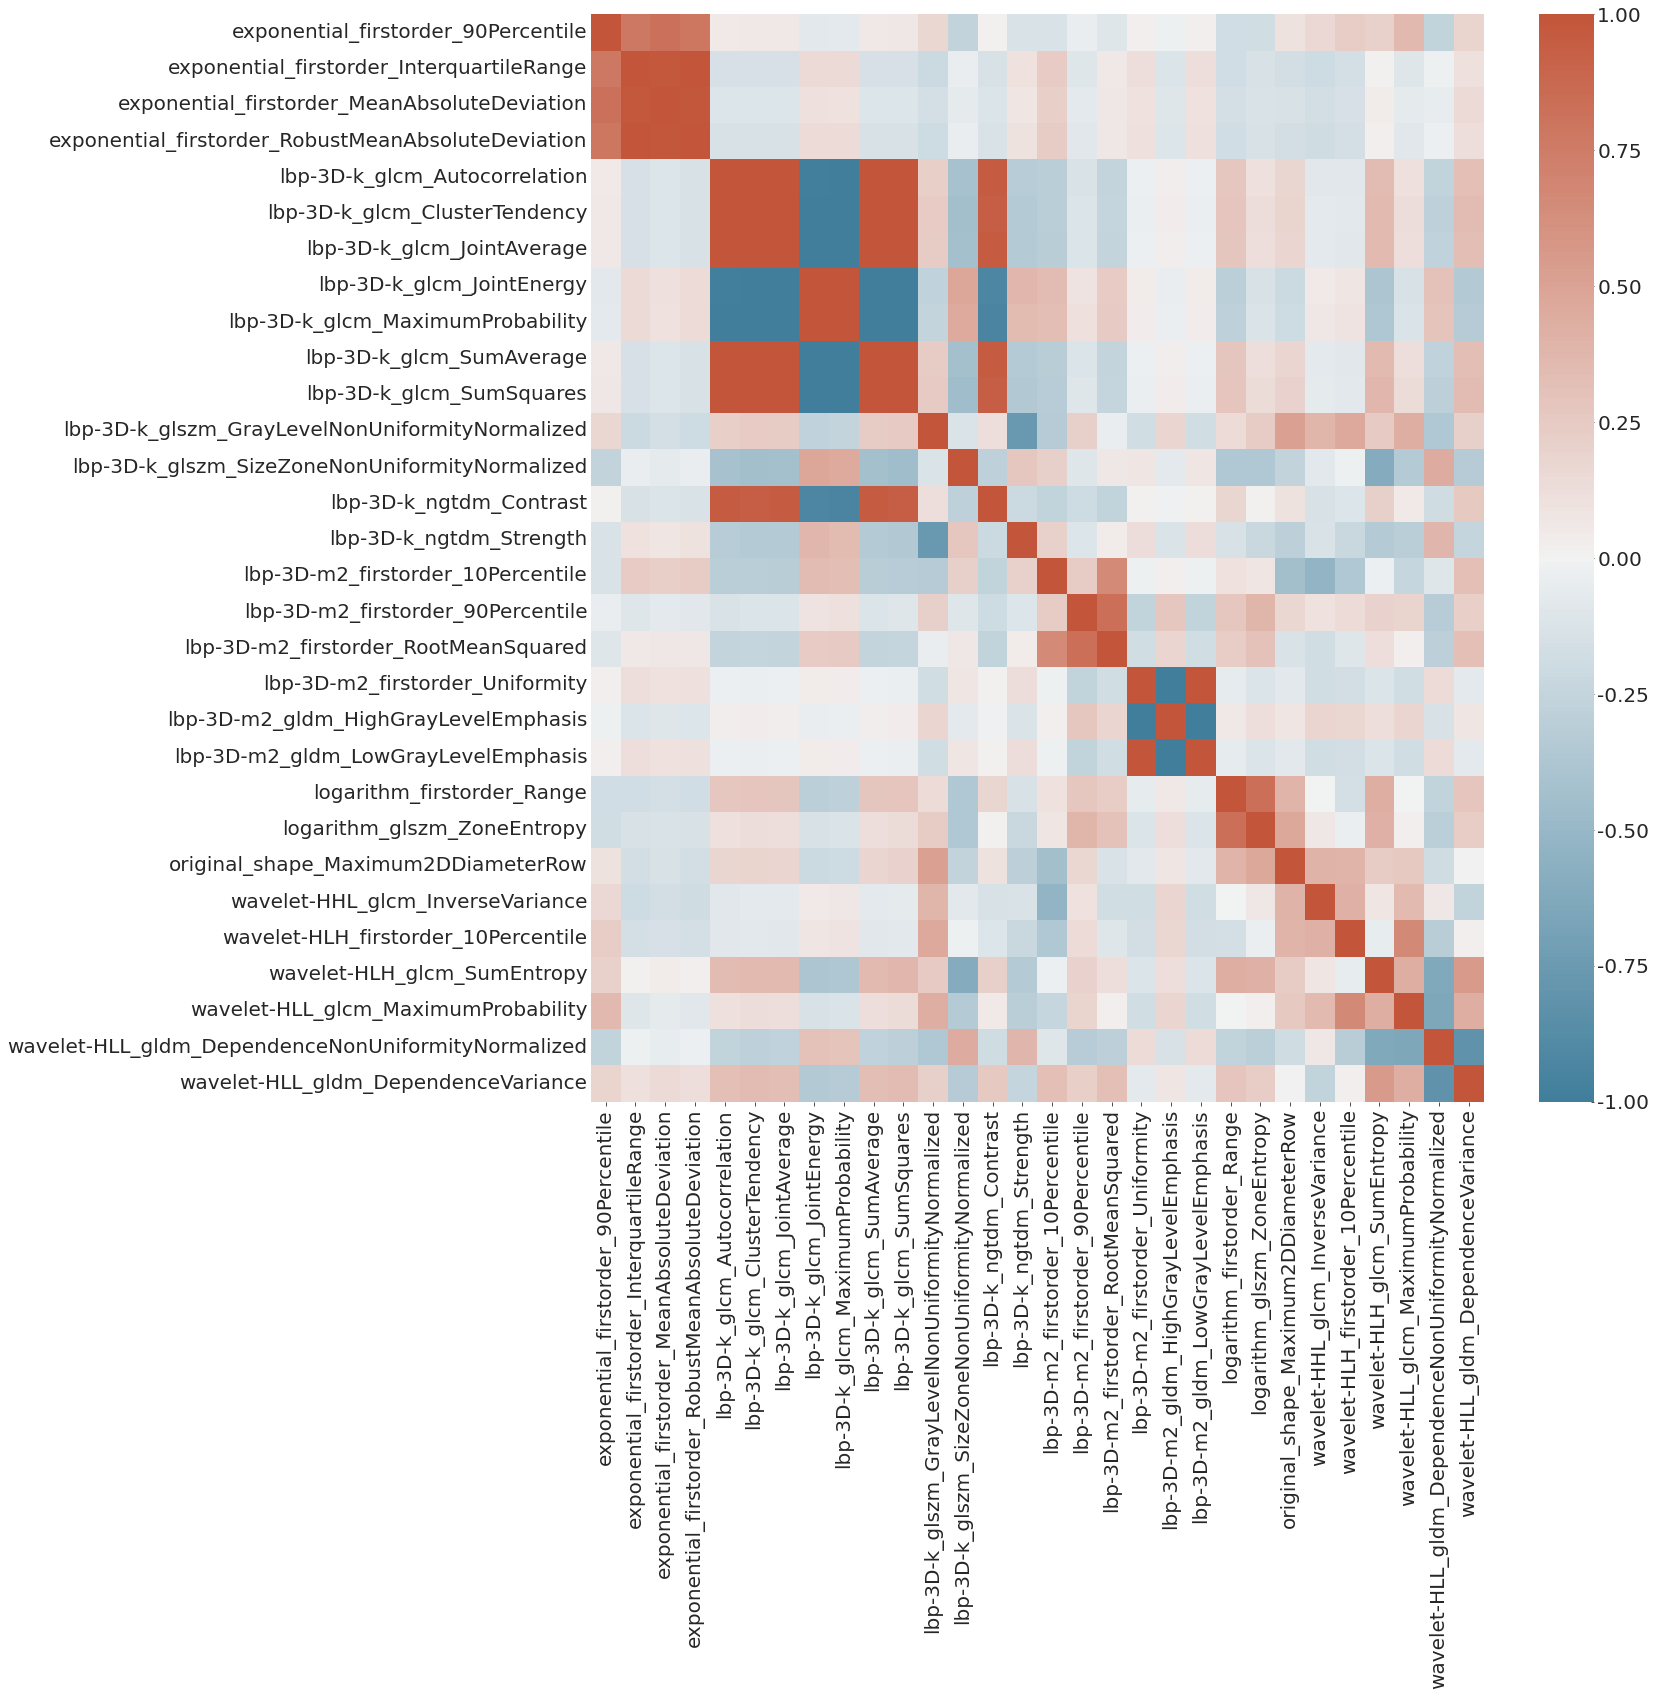

In [55]:
plt.figure(figsize=(20,20))

model = 'LR Rad-PC'
sns.heatmap( 
    df_radiology \
        .query('job_tag == "filtered-radiomics"')
        [summary_coefs[model].columns[~summary_coefs[model].loc['coef'].iloc[0].isna()]].corr(),
cmap=sns.diverging_palette(230, 20, as_cmap=True), center=0,)

# Code graveyard

In [56]:
# exhumed